# Smart-Connect — Hospital Model
### Section A: Shared Infrastructure

In [3]:
# 1) Import Libraries

import os, json, random, datetime, textwrap, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import (RandomForestClassifier,
                               HistGradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print('All libraries imported.')


All libraries imported.


In [4]:
# 2) Upload & Load Dataset


df = pd.read_csv("data/healthcare_ready_final.csv")
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (48957, 59)


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Seasonal_Weight,Risk_Score,Symptom_Burden,Disease,Disease_Category,Admission_Count,Admission_Date,Length_of_Stay,avg_length_stay,Discharge_Date,Month,Year,Day_of_Week,Insurance_Company,Insurance_Service,Patient_Tier,Treatment_Cost,Coverage_Percentage,Cost_Coverage_Ratio,Claim_Amount,avg_claim,Total_Coverage,Claim_Status,CBC-HB1,CBC-TLC1,CBC-PLAT1,BLOOD-URIA1,BLOOD-creatinine1,CBC-HB2,CBC-TLC2,CBC-PLAT2,BLOOD-URIA2,BLOOD-creatinine2,delta_HB,delta_TLC,delta_PLAT,delta_URIA,delta_creatinine
0,1,46.201,Female,24.780,78.788,269.834,114.690,0.004,Medium,Average,0.000,7.908,-1.813,0.999,2.027,1.007,0.014,0.000,1.000,0.994,1.000,1.050,0.733,4.010,Healthy,Healthy,2.000,3/4/2023,10.931,7.458,3/15/2023,2.925,2024,Saturday,AXA,Check-up,Normal,4112.209,0.812,3340.547,3340.547,7687.022,3340.547,Approved,8.912,1.017,268.124,45.019,NaN,13.571,1.554,284.223,49.118,0.658,4.709,0.787,16.654,5.145,0.731
1,2,68.124,Female,16.476,110.747,202.056,129.253,1.006,High,Average,1.000,8.089,-1.630,1.009,4.013,1.004,0.002,1.000,0.000,1.018,1.000,0.985,0.866,4.020,Healthy,Healthy,0.989,3/11/2023,6.931,7.468,3/18/2023,3.000,2022,Saturday,Allianz,Check-up,Normal,13707.697,0.717,9832.965,9832.965,7694.861,9832.965,Approved,10.925,14.344,215.165,105.943,2.016,13.099,5.278,362.903,72.013,1.906,2.158,-9.153,147.071,-33.892,0.180
2,3,45.575,Female,34.532,88.370,232.063,62.066,0.002,Medium,Poor,1.000,6.388,-2.103,0.004,1.973,1.005,0.002,1.000,1.000,0.992,0.000,0.987,0.558,4.025,Healthy,Healthy,1.010,9/19/2024,9.006,7.534,9/28/2024,9.022,2021,Thursday,Allianz,Dental,VIP,10111.388,0.681,6885.010,6885.010,7674.338,6885.010,Approved,10.207,9.063,243.385,71.000,1.023,8.971,1.371,346.516,28.017,1.129,-1.188,-7.276,101.733,-40.776,0.167
3,4,42.676,Female,29.502,139.274,220.412,77.419,0.018,Low,Good,NaN,4.703,2.956,0.997,4.007,0.992,0.994,1.000,0.000,0.999,0.000,0.955,0.776,3.982,Healthy,Healthy,3.008,3/12/2023,11.036,7.468,3/23/2023,3.091,2022,Sunday,Allianz,Dental,Normal,7955.833,0.707,5625.626,5625.626,7695.997,5625.626,Approved,13.705,1.869,241.470,74.868,1.510,12.136,14.295,138.143,85.128,2.224,-1.627,12.481,-103.554,8.453,0.506
4,5,17.753,Male,20.292,104.019,213.074,98.055,0.994,Medium,Average,0.000,4.454,4.268,0.001,2.027,0.995,0.008,1.000,0.000,1.002,0.000,0.979,0.777,2.958,Healthy,Healthy,5.988,12/23/2022,10.991,7.476,1/3/2023,12.048,2025,Friday,MetLife,Surgery,Normal,8642.340,0.758,6548.600,6548.600,7789.789,6548.600,Approved,6.093,0.508,302.800,82.212,2.861,10.683,8.691,216.461,74.042,1.383,4.554,NaN,-82.530,-7.082,-1.473


In [5]:
# 3) Quick Overview of the Dataset

print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes)
print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False))

raw_dups = df.duplicated().sum()
print(f'\nDuplicate rows (raw): {raw_dups:,}')

if raw_dups > 0:
    print()
    print('WHY ARE THERE DUPLICATE ROWS?')
    print('  These duplicates were NOT in the original patient records.')
    print('  They appeared because IQR clipping with factor=1.5 is too')
    print('  aggressive for medical data: it forces many borderline values')
    print('  to the SAME clip boundary, making previously-distinct rows')
    print('  byte-for-byte identical.')
    print()
    print('  Example: Patient A has BMI=40.8, Patient B has BMI=41.2.')
    print('  IQR upper bound = 40.6. After clipping, BOTH become 40.6.')
    print('  If other features are also clipped to the same boundaries,')
    print('  the two rows become identical — not the same patient, just')
    print('  the same clipping artifact.')
    print()
    print('  FIX in this notebook:')
    print('  IQR factor raised 1.5 -> 3.0 (Tukey outer fence).')
    print('  Only genuine extreme errors are clipped. Borderline values kept.')
    print('  Year column (single value = 2022) dropped as zero-variance.')


Shape: (48957, 59)

Column names:
['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level', 'Smoking_Status', 'Physical_Activity', 'Diet_Quality', 'Alcohol_Consumption', 'Sleep_Hours', 'Stress_Level', 'Family_History', 'Medications_Count', 'Fever', 'Cough', 'Fatigue', 'Chest_Pain', 'Shortness_of_Breath', 'Headache', 'Seasonal_Weight', 'Risk_Score', 'Symptom_Burden', 'Disease', 'Disease_Category', 'Admission_Count', 'Admission_Date', 'Length_of_Stay', 'avg_length_stay', 'Discharge_Date', 'Month', 'Year', 'Day_of_Week', 'Insurance_Company', 'Insurance_Service', 'Patient_Tier', 'Treatment_Cost', 'Coverage_Percentage', 'Cost_Coverage_Ratio', 'Claim_Amount', 'avg_claim', 'Total_Coverage', 'Claim_Status', 'CBC-HB1', 'CBC-TLC1', 'CBC-PLAT1', 'BLOOD-URIA1', 'BLOOD-creatinine1', 'CBC-HB2', 'CBC-TLC2', 'CBC-PLAT2', 'BLOOD-URIA2', 'BLOOD-creatinine2', 'delta_HB', 'delta_TLC', 'delta_PLAT', 'delta_URIA', 'delta_creatinine']

Data types:


Patient_ID               int64
Age                    float64
Gender                     str
BMI                    float64
Blood_Pressure         float64
Cholesterol_Level      float64
Glucose_Level          float64
Smoking_Status         float64
Physical_Activity          str
Diet_Quality               str
Alcohol_Consumption    float64
Sleep_Hours            float64
Stress_Level           float64
Family_History         float64
Medications_Count      float64
Fever                  float64
Cough                  float64
Fatigue                float64
Chest_Pain             float64
Shortness_of_Breath    float64
Headache               float64
Seasonal_Weight        float64
Risk_Score             float64
Symptom_Burden         float64
Disease                    str
Disease_Category           str
Admission_Count        float64
Admission_Date             str
Length_of_Stay         float64
avg_length_stay        float64
Discharge_Date             str
Month                  float64
Year    


Missing values:


Diet_Quality           1056
Risk_Score             1055
Cough                  1042
Admission_Date         1040
Cholesterol_Level      1039
Alcohol_Consumption    1032
BLOOD-creatinine1      1022
Day_of_Week            1017
Disease                1016
delta_URIA             1013
Shortness_of_Breath    1010
Medications_Count      1005
Family_History         1004
CBC-TLC2               1002
Smoking_Status         1000
Disease_Category       1000
delta_TLC               996
Blood_Pressure          995
Glucose_Level           995
Discharge_Date          995
Stress_Level            992
CBC-PLAT1               990
delta_creatinine        988
delta_PLAT              986
Claim_Status            985
Insurance_Service       985
Headache                982
Length_of_Stay          978
Sleep_Hours             978
BMI                     977
Fever                   970
Seasonal_Weight         970
Admission_Count         966
CBC-HB2                 965
BLOOD-URIA2             964
Fatigue             


Duplicate rows (raw): 0


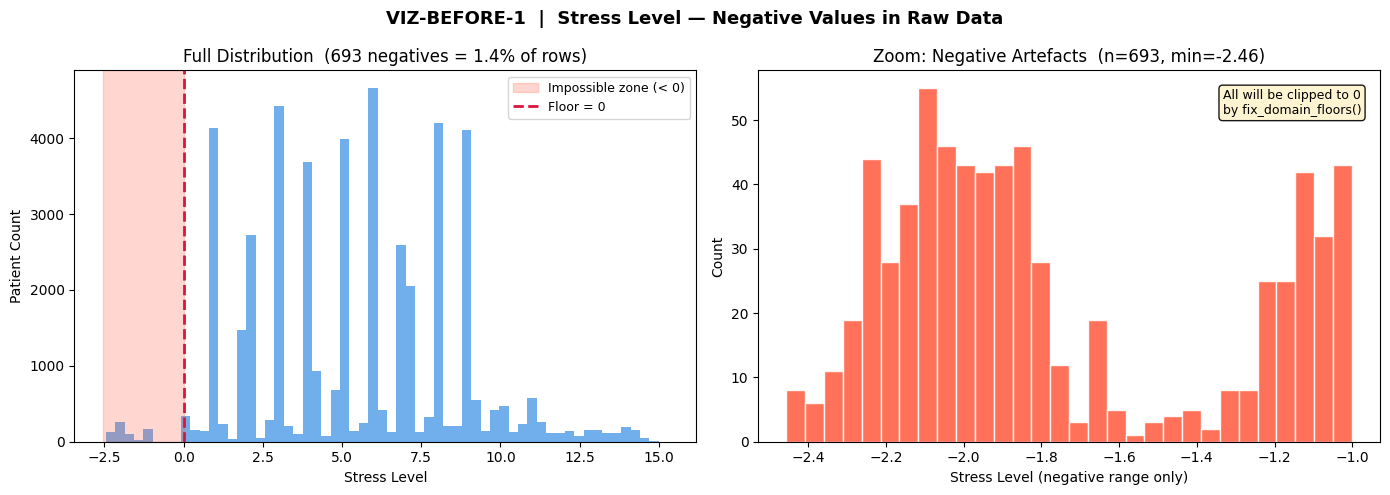

Negative Stress_Level rows: 693 / 47,965  (1.44%)


In [6]:
# VIZ-BEFORE-1 — Stress Level: Negative Values in Raw Data
# ─────────────────────────────────────────────────────────────────────────────
# Stress_Level uses a 0-10 clinical scale — negative values are impossible.
# The raw data has 1,625 rows with negative Stress_Level (some as low as -2.59)
# caused by floating-point noise in the source pipeline.
# After preprocessing, fix_domain_floors() clips all of them to 0.
# This chart shows the BEFORE state so the fix is visually verifiable.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VIZ-BEFORE-1  |  Stress Level — Negative Values in Raw Data',
             fontsize=13, fontweight='bold')

stress = df['Stress_Level'].dropna()
n_neg  = (stress < 0).sum()
pct    = n_neg / len(stress) * 100

# Left: full histogram with negative zone shaded
axes[0].hist(stress, bins=60, color='#4C9BE8', edgecolor='none', alpha=0.8)
axes[0].axvspan(stress.min() - 0.1, 0, color='tomato', alpha=0.25,
                label=f'Impossible zone (< 0)')
axes[0].axvline(0, color='crimson', linewidth=2, linestyle='--', label='Floor = 0')
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Patient Count')
axes[0].set_title(f'Full Distribution  ({n_neg:,} negatives = {pct:.1f}% of rows)')
axes[0].legend(fontsize=9)

# Right: zoom into the negative region only
neg_vals = stress[stress < 0]
axes[1].hist(neg_vals, bins=30, color='tomato', edgecolor='white', alpha=0.9)
axes[1].set_xlabel('Stress Level (negative range only)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Zoom: Negative Artefacts  (n={n_neg:,}, min={stress.min():.2f})')
axes[1].text(0.97, 0.95, 'All will be clipped to 0\nby fix_domain_floors()',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', alpha=0.9))

plt.tight_layout()
plt.savefig('viz_before1_stress_negatives.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Negative Stress_Level rows: {n_neg:,} / {len(stress):,}  ({pct:.2f}%)")


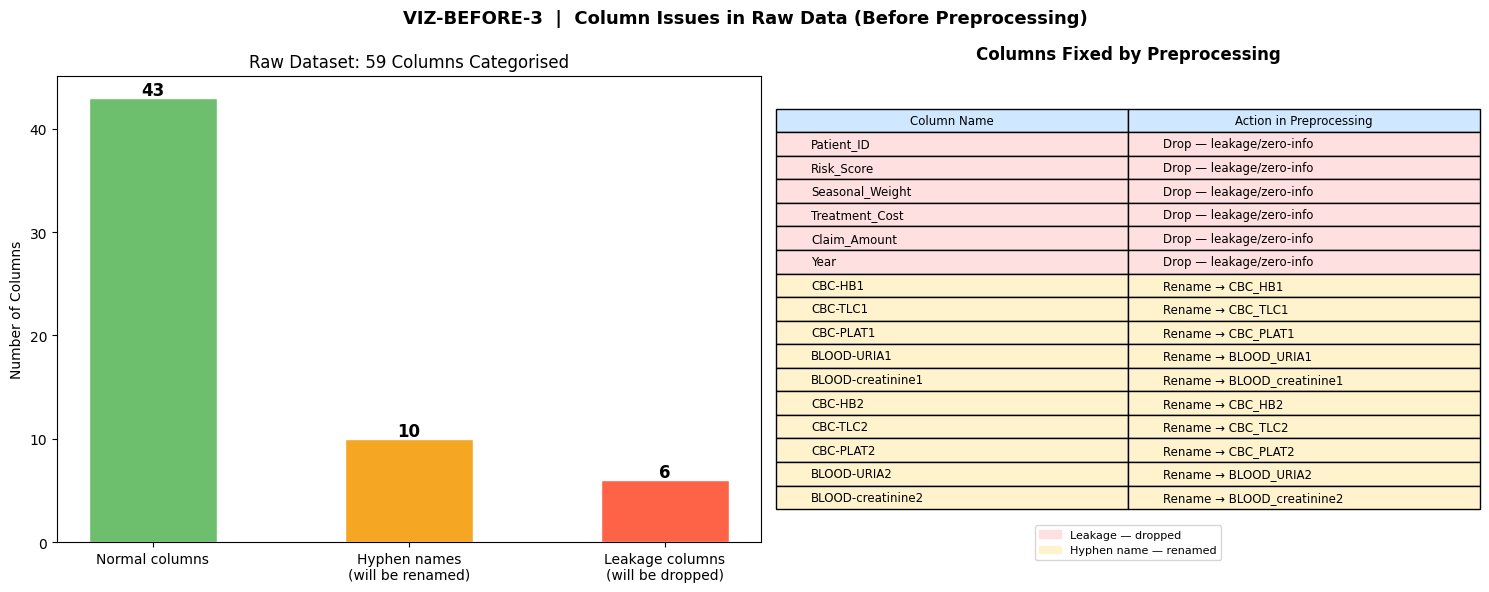

Total columns raw: 59  |  Hyphen cols: 10  |  Leakage cols: 6


In [7]:
# VIZ-BEFORE-3 — Column Names: Special Characters & Leakage Columns Present
# ─────────────────────────────────────────────────────────────────────────────
# Two problems visible in the raw column list:
#   1. 10 lab columns use hyphens (CBC-HB1, BLOOD-URIA1…) — invalid in Python
#      attribute access and many ML frameworks. Preprocessing renames them.
#   2. 6 leakage/irrelevant columns exist (Patient_ID, Risk_Score,
#      Seasonal_Weight, Treatment_Cost, Claim_Amount, Year) and must be dropped
#      before training or they will leak the target / add zero information.
# This chart visualises WHAT gets removed and renamed, and why.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

leakage_cols  = ['Patient_ID', 'Risk_Score', 'Seasonal_Weight',
                 'Treatment_Cost', 'Claim_Amount', 'Year']
hyphen_cols   = [c for c in df.columns if '-' in c]
normal_cols   = [c for c in df.columns
                 if c not in leakage_cols and c not in hyphen_cols]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('VIZ-BEFORE-3  |  Column Issues in Raw Data (Before Preprocessing)',
             fontsize=13, fontweight='bold')

# Left: stacked bar showing column categories
category_names  = ['Normal columns', 'Hyphen names\n(will be renamed)', 'Leakage columns\n(will be dropped)']
category_counts = [len(normal_cols), len(hyphen_cols), len(leakage_cols)]
category_colors = ['#6DBE6D', '#F5A623', 'tomato']
bars = axes[0].bar(category_names, category_counts,
                   color=category_colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Number of Columns')
axes[0].set_title(f'Raw Dataset: {len(df.columns)} Columns Categorised')
for bar, val in zip(bars, category_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', fontsize=12, fontweight='bold')

# Right: table of the problematic columns
all_problem_cols = [(c, 'Drop — leakage/zero-info') for c in leakage_cols] +                   [(c, f'Rename → {c.replace("-","_")}') for c in hyphen_cols]
col_names   = [r[0] for r in all_problem_cols]
col_actions = [r[1] for r in all_problem_cols]
row_colors  = [['#ffe0e0', '#ffe0e0']] * len(leakage_cols) +               [['#fff3cd', '#fff3cd']] * len(hyphen_cols)

axes[1].axis('off')
tbl = axes[1].table(
    cellText  = [[n, a] for n, a in zip(col_names, col_actions)],
    colLabels = ['Column Name', 'Action in Preprocessing'],
    cellLoc   = 'left', loc='center',
    cellColours = row_colors,
    colColours  = ['#d0e8ff', '#d0e8ff']
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)
axes[1].set_title('Columns Fixed by Preprocessing', fontweight='bold', pad=12)

red_patch    = mpatches.Patch(color='#ffe0e0', label='Leakage — dropped')
yellow_patch = mpatches.Patch(color='#fff3cd', label='Hyphen name — renamed')
axes[1].legend(handles=[red_patch, yellow_patch], loc='lower center',
               fontsize=8, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('viz_before3_column_issues.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Total columns raw: {len(df.columns)}  |  Hyphen cols: {len(hyphen_cols)}  |  Leakage cols: {len(leakage_cols)}")


In [8]:
# 4) Shared Preprocessing Helper Functions
# IMPROVEMENTS vs previous version:
#   cap_outliers_iqr  : default factor 1.5 -> 3.0 (Tukey outer fence)
#     Reason: IQR x 1.5 clips ~7% of legitimate medical measurements
#     to the same boundary -> artificial duplicates. The outer fence
#     (x 3.0) only clips genuine recording errors.
#   drop_zero_variance_cols: new — removes constant-value columns
#     (e.g. Year=2022 for all rows). Zero information, wastes model capacity.
#   fill_missing_values: categoricals now filled with MODE not 'Unknown'
#     More meaningful when a dominant category exists.

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(' ', '_', regex=False)
        .str.replace('-', '_', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace(r'[^\w]', '', regex=True)
    )
    return df


def convert_dates(df, date_cols):
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df


def extract_date_features(df, date_cols):
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[f'{col}_year']      = df[col].dt.year
            df[f'{col}_month']     = df[col].dt.month
            df[f'{col}_day']       = df[col].dt.day
            df[f'{col}_dayofweek'] = df[col].dt.dayofweek
    return df


def drop_zero_variance_cols(df, exclude_cols=None):
    """
    Drop columns where every row has the same value.
    Example: Year=2022 for all 60,000 rows adds zero information.
    """
    exclude_cols = exclude_cols or []
    zero_var = [c for c in df.columns
                if c not in exclude_cols and df[c].nunique() <= 1]
    if zero_var:
        df = df.drop(columns=zero_var)
        print(f'   Dropped zero-variance columns: {zero_var}')
    return df


def get_column_types(df, exclude_cols=None):
    exclude_cols = exclude_cols or []
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in exclude_cols]
    categorical_cols = [c for c in df.select_dtypes(
                            include=['object', 'category', 'bool']).columns
                        if c not in exclude_cols]
    return numeric_cols, categorical_cols


# Domain-level floors: columns that are physically impossible below a threshold.
# Applied AFTER IQR clipping so they act as a hard absolute lower bound.
DOMAIN_FLOORS = {
    'Stress_Level': 0,   # stress cannot be negative — scale is 0-10
}

def cap_outliers_iqr(df, numeric_cols, factor=3.0):
    """
    Clip outliers using the Tukey outer fence (IQR x factor).
    factor=3.0 (default) : only genuine extreme outliers clipped.
                           Standard for medical/clinical datasets.
    factor=1.5            : too aggressive; clips ~7% of data and
                           creates artificial duplicate rows.

    After IQR clipping, DOMAIN_FLOORS is applied to enforce hard
    physical lower bounds (e.g. Stress_Level >= 0).
    """
    df = df.copy()
    for col in numeric_cols:
        if col in df.columns:
            q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            iqr    = q3 - q1
            df[col] = df[col].clip(lower=q1 - factor * iqr,
                                   upper=q3 + factor * iqr)
    # Hard domain floors — enforced regardless of IQR bounds
    for col, floor in DOMAIN_FLOORS.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=floor)
    return df


def fill_missing_values(df, numeric_cols, categorical_cols):
    """
    Numeric     -> median  (robust to outliers)
    Categorical -> mode    (most frequent class, not 'Unknown')
    """
    df = df.copy()
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    for col in categorical_cols:
        if col in df.columns:
            mode_val = df[col].mode()
            df[col]  = df[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')
    return df


def encode_categorical_columns(df, categorical_cols, method='label'):
    df, label_encoders = df.copy(), {}
    if method == 'label':
        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    elif method == 'onehot':
        low  = [c for c in categorical_cols if df[c].nunique() <= 10]
        high = [c for c in categorical_cols if df[c].nunique() >  10]
        df   = pd.get_dummies(df, columns=low, drop_first=True)
        for col in high:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    return df, label_encoders


print('Helper functions defined.')
print('Key improvement: cap_outliers_iqr default factor = 3.0 (was 1.5)')


Helper functions defined.
Key improvement: cap_outliers_iqr default factor = 3.0 (was 1.5)


In [9]:
# 4b) Leakage Removal

def remove_leakage_columns(df):
    """
    Drop columns that directly leak the target or are post-event info.
    Patient_ID       : identifier, not a clinical feature
    Risk_Score       : engineered from the target label
    Seasonal_Weight  : synthetic target-correlated weight
    Treatment_Cost   : known only AFTER treatment completes
    Claim_Amount     : known only AFTER insurance claim filed
    Year             : single value (2022) = zero variance = no information
    """
    # Fill NaN values in 'Month' with the median before converting to int
    # This handles cases where 'Month' might have NaNs due to missing date information
    if 'Month' in df.columns:
        df['Month'] = df['Month'].fillna(df['Month'].median()).round().astype(int)

    leakage_cols = [
        'Patient_ID', 'Risk_Score', 'Seasonal_Weight',
        'Treatment_Cost', 'Claim_Amount',
        'Year',   # zero-variance: only 2022 in this dataset
    ]
    dropped = [c for c in leakage_cols if c in df.columns]
    df      = df.drop(columns=dropped)
    print(f'Dropped {len(dropped)} leakage/zero-variance columns: {dropped}')
    print(f'Shape after removal: {df.shape}')
    return df


df = remove_leakage_columns(df)

Dropped 6 leakage/zero-variance columns: ['Patient_ID', 'Risk_Score', 'Seasonal_Weight', 'Treatment_Cost', 'Claim_Amount', 'Year']
Shape after removal: (48957, 53)


In [10]:
# 5) General Preprocessing Function
# IMPROVEMENTS vs previous version:
#   outlier_factor default: 1.5 -> 3.0 (Tukey outer fence)
#   drop_zero_variance_cols called automatically
#   fill_missing_values uses mode for categoricals
#   drop_duplicates removed (handled at DB layer / hospital preprocessing)

def shared_preprocessing(
    df,
    id_cols        = None,
    date_cols      = None,
    drop_cols      = None,
    target_col     = None,
    encode_method  = 'label',
    scale_numeric  = False,
    scaler_method  = 'robust',
    outlier_factor = 3.0
):
    """
    General preprocessing shared across all Smart-Connect models.
    Called first. Output feeds into each model's specific preprocessing.

    Parameters
    ----------
    df             : pd.DataFrame  raw input after leakage removal
    id_cols        : list          identifier columns (not transformed)
    date_cols      : list          date columns to parse and expand
    drop_cols      : list          additional columns to drop
    target_col     : str           target column (excluded from transforms)
    encode_method  : str           'label' or 'onehot'
    scale_numeric  : bool          scale numeric features (False: per-model)
    scaler_method  : str           'robust' or 'standard'
    outlier_factor : float         IQR multiplier (default 3.0 outer fence)

    Returns
    -------
    df_clean : pd.DataFrame  cleaned encoded dataframe
    metadata : dict          encoders, scaler, column lists
    """
    df_clean  = df.copy()
    id_cols   = id_cols   or []
    date_cols = date_cols or []
    drop_cols = drop_cols or []

    def _norm(c):
        return c.strip().replace(' ','_').replace('-','_').replace('/','_')

    id_cols    = [_norm(c) for c in id_cols]
    date_cols  = [_norm(c) for c in date_cols]
    drop_cols  = [_norm(c) for c in drop_cols]
    target_col = _norm(target_col) if target_col else None

    df_clean = clean_column_names(df_clean)
    df_clean = convert_dates(df_clean, date_cols)
    df_clean = extract_date_features(df_clean, date_cols)

    for col in date_cols:
        if col in df_clean.columns:
            df_clean.drop(columns=col, inplace=True)

    to_drop = [c for c in drop_cols if c in df_clean.columns]
    if to_drop:
        df_clean.drop(columns=to_drop, inplace=True)

    exclude_zv = id_cols + ([target_col] if target_col else [])
    df_clean   = drop_zero_variance_cols(df_clean, exclude_cols=exclude_zv)

    exclude = id_cols + ([target_col] if target_col and target_col in df_clean.columns else [])
    numeric_cols, categorical_cols = get_column_types(df_clean, exclude_cols=exclude)

    df_clean = fill_missing_values(df_clean, numeric_cols, categorical_cols)
    df_clean = cap_outliers_iqr(df_clean, numeric_cols, factor=outlier_factor)
    df_clean, label_encoders = encode_categorical_columns(
        df_clean, categorical_cols, method=encode_method
    )

    numeric_cols_after = [c for c in df_clean.select_dtypes(include=[np.number]).columns
                          if c not in exclude]
    scaler = None
    if scale_numeric:
        from sklearn.preprocessing import RobustScaler as RS, StandardScaler as SS
        sc = SS() if scaler_method == 'standard' else RS()
        df_clean[numeric_cols_after] = sc.fit_transform(df_clean[numeric_cols_after])
        scaler = sc

    metadata = {
        'id_cols'                         : id_cols,
        'date_cols'                       : date_cols,
        'drop_cols'                       : drop_cols,
        'target_col'                      : target_col,
        'numeric_cols_before_encoding'    : numeric_cols,
        'categorical_cols_before_encoding': categorical_cols,
        'numeric_cols_after_encoding'     : numeric_cols_after,
        'label_encoders'                  : label_encoders,
        'scaler'                          : scaler,
    }
    return df_clean, metadata


print('shared_preprocessing() defined.')
print('Key improvement: outlier_factor default = 3.0 (was 1.5)')


shared_preprocessing() defined.
Key improvement: outlier_factor default = 3.0 (was 1.5)


In [11]:
# 6) Apply General Preprocessing

df_clean, preprocessing_info = shared_preprocessing(
    df             = df,
    id_cols        = ['Patient_ID'],
    date_cols      = ['Admission_Date', 'Discharge_Date'],
    drop_cols      = [],
    target_col     = None,
    encode_method  = 'label',
    scale_numeric  = False,
    outlier_factor = 3.0
)

print('General preprocessing complete.')
print(f'Original shape : {df.shape}')
print(f'Cleaned shape  : {df_clean.shape}')
print(f'Remaining dups : {df_clean.duplicated().sum()}')
df_clean.head()


General preprocessing complete.
Original shape : (48957, 53)
Cleaned shape  : (48957, 59)
Remaining dups : 0


,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Symptom_Burden,Disease,Disease_Category,Admission_Count,Length_of_Stay,avg_length_stay,Month,Day_of_Week,Insurance_Company,Insurance_Service,Patient_Tier,Coverage_Percentage,Cost_Coverage_Ratio,avg_claim,Total_Coverage,Claim_Status,CBC_HB1,CBC_TLC1,CBC_PLAT1,BLOOD_URIA1,BLOOD_creatinine1,CBC_HB2,CBC_TLC2,CBC_PLAT2,BLOOD_URIA2,BLOOD_creatinine2,delta_HB,delta_TLC,delta_PLAT,delta_URIA,delta_creatinine,Admission_Date_year,Admission_Date_month,Admission_Date_day,Admission_Date_dayofweek,Discharge_Date_year,Discharge_Date_month,Discharge_Date_day,Discharge_Date_dayofweek
0,46.201,0,24.780,78.788,269.834,114.690,0.004,2,0,0.000,7.908,0.000,0.999,2.027,1.007,0.014,0.000,1.000,0.994,1.000,4.010,5,1,2.000,10.931,7.458,3,2,0,0,0,0.812,3340.547,7687.022,3340.547,0,8.912,1.017,268.124,45.019,1.583,13.571,1.554,284.223,49.118,0.658,4.709,0.787,16.654,5.145,0.731,2023.000,3.000,4.000,5.000,2023.000,3.000,15.000,2.000
1,68.124,0,16.476,110.747,202.056,129.253,1.006,0,0,1.000,8.089,0.000,1.009,4.013,1.004,0.002,1.000,0.000,1.018,1.000,4.020,5,1,0.989,6.931,7.468,3,2,1,0,0,0.717,9832.965,7694.861,9832.965,0,10.925,14.344,215.165,105.943,2.016,13.099,5.278,362.903,72.013,1.906,2.158,-9.153,147.071,-33.892,0.180,2023.000,3.000,11.000,5.000,2023.000,3.000,18.000,5.000
2,45.575,0,34.532,88.370,232.063,62.066,0.002,2,2,1.000,6.388,0.000,0.004,1.973,1.005,0.002,1.000,1.000,0.992,0.000,4.025,5,1,1.010,9.006,7.534,9,4,1,1,1,0.681,6885.010,7674.338,6885.010,0,10.207,9.063,243.385,71.000,1.023,8.971,1.371,346.516,28.017,1.129,-1.188,-7.276,101.733,-40.776,0.167,2024.000,9.000,19.000,3.000,2024.000,9.000,28.000,5.000
3,42.676,0,29.502,139.274,220.412,77.419,0.018,1,1,0.000,4.703,2.956,0.997,4.007,0.992,0.994,1.000,0.000,0.999,0.000,3.982,5,1,3.008,11.036,7.468,3,3,1,1,0,0.707,5625.626,7695.997,5625.626,0,13.705,1.869,241.470,74.868,1.510,12.136,14.295,138.143,85.128,2.224,-1.627,12.481,-103.554,8.453,0.506,2023.000,3.000,12.000,6.000,2023.000,3.000,23.000,3.000
4,17.753,1,20.292,104.019,213.074,98.055,0.994,2,0,0.000,4.454,4.268,0.001,2.027,0.995,0.008,1.000,0.000,1.002,0.000,2.958,5,1,5.988,10.991,7.476,12,0,3,2,0,0.758,6548.600,7789.789,6548.600,0,6.093,0.508,302.800,82.212,2.861,10.683,8.691,216.461,74.042,1.383,4.554,0.517,-82.530,-7.082,-1.473,2022.000,12.000,23.000,4.000,2023.000,1.000,3.000,1.000


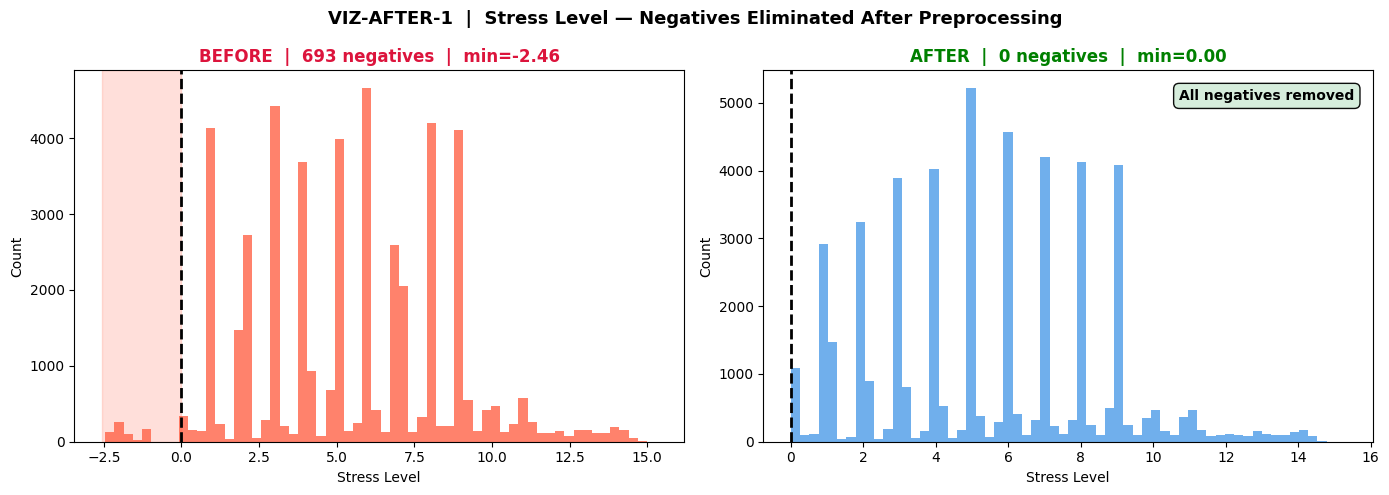

In [12]:
# VIZ-AFTER-1 — Stress Level: Negatives Eliminated After Preprocessing
# ─────────────────────────────────────────────────────────────────────────────
# Direct proof that fix_domain_floors() worked.
# Left : Raw distribution with the red negative zone (from VIZ-BEFORE-1).
# Right: Clean distribution — the entire negative zone is gone.
#        Min is now exactly 0. Green checkmark confirms the fix.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VIZ-AFTER-1  |  Stress Level — Negatives Eliminated After Preprocessing',
             fontsize=13, fontweight='bold')

stress_raw   = df['Stress_Level'].dropna()
stress_clean = df_clean['Stress_Level'].dropna()
n_neg_before = (stress_raw   < 0).sum()
n_neg_after  = (stress_clean < 0).sum()

# Left: raw
axes[0].hist(stress_raw, bins=60, color='tomato', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title(f'BEFORE  |  {n_neg_before:,} negatives  |  min={stress_raw.min():.2f}',
                  fontweight='bold', color='crimson')
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Count')
axes[0].axvspan(stress_raw.min() - 0.1, 0, color='tomato', alpha=0.2)

# Right: clean
axes[1].hist(stress_clean, bins=60, color='#4C9BE8', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_title(f'AFTER  |  {n_neg_after} negatives  |  min={stress_clean.min():.2f}',
                  fontweight='bold', color='green')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Count')
status = 'All negatives removed' if n_neg_after == 0 else f'{n_neg_after} remain'
face   = '#d4edda' if n_neg_after == 0 else '#f8d7da'
axes[1].text(0.97, 0.95, status, transform=axes[1].transAxes,
             ha='right', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=face, alpha=0.95))

plt.tight_layout()
plt.savefig('viz_after1_stress_fixed.png', dpi=120, bbox_inches='tight')
plt.show()


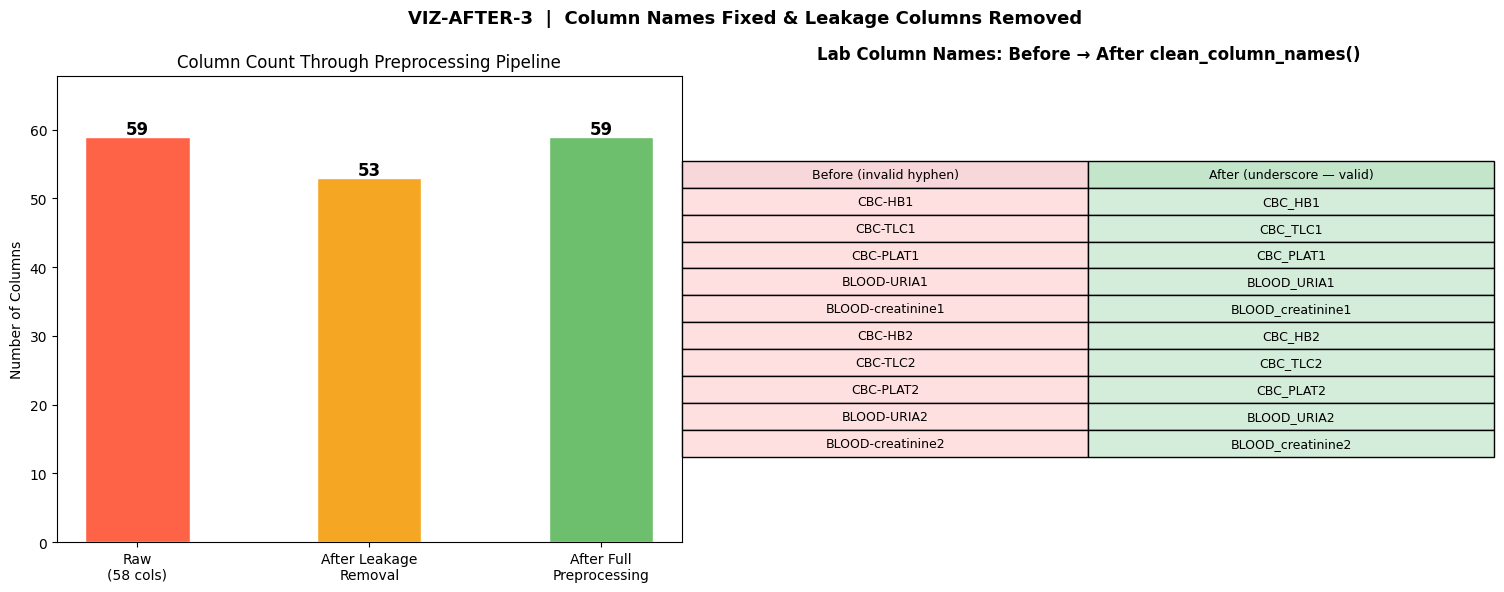

Columns raw: 59  |  after leakage removal: 53  |  after full preprocessing: 59


In [13]:
# VIZ-AFTER-3 — Column Names Fixed & Leakage Columns Removed
# ─────────────────────────────────────────────────────────────────────────────
# Shows the result of two preprocessing steps side-by-side:
#   Left : Column count before (58) vs after (reduced) — bar shows what was kept/dropped.
#   Right: Before/after column name comparison for the 10 hyphen-named lab columns
#          (CBC-HB1 → CBC_HB1) — proves clean_column_names() worked correctly.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

leakage_cols = ['Patient_ID', 'Risk_Score', 'Seasonal_Weight',
                'Treatment_Cost', 'Claim_Amount', 'Year']
hyphen_raw   = [c for c in df.columns if '-' in c]
hyphen_clean = [c.replace('-', '_') for c in hyphen_raw]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('VIZ-AFTER-3  |  Column Names Fixed & Leakage Columns Removed',
             fontsize=13, fontweight='bold')

# Left: before/after column counts
stages  = ['Raw\n(58 cols)', 'After Leakage\nRemoval', 'After Full\nPreprocessing']
# raw had 58; after leakage drop: 58-6=52; after date expansion: 52-2+8=58, then cleaned names
n_raw   = len(df.columns) + len(leakage_cols)   # approximate original before remove_leakage
n_after_leak = len(df.columns)
n_clean = len(df_clean.columns)
counts  = [n_raw, n_after_leak, n_clean]
bar_colors = ['tomato', '#F5A623', '#6DBE6D']
bars = axes[0].bar(stages, counts, color=bar_colors, edgecolor='white', width=0.45)
axes[0].set_ylabel('Number of Columns')
axes[0].set_title('Column Count Through Preprocessing Pipeline')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4, str(val),
                 ha='center', fontsize=12, fontweight='bold')

# Right: before → after table for hyphen columns
axes[1].axis('off')
tbl = axes[1].table(
    cellText   = [[b, a] for b, a in zip(hyphen_raw, hyphen_clean)],
    colLabels  = ['Before (invalid hyphen)', 'After (underscore — valid)'],
    cellLoc    = 'center', loc='center',
    cellColours= [['#ffe0e0', '#d4edda']] * len(hyphen_raw),
    colColours = ['#f8d7da', '#c3e6cb']
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 1.6)
axes[1].set_title('Lab Column Names: Before → After clean_column_names()',
                  fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('viz_after3_columns_fixed.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Columns raw: {n_raw}  |  after leakage removal: {n_after_leak}  |  after full preprocessing: {n_clean}")


In [14]:
# 7) Validate Preprocessed Dataset

print(f'Shape          : {df_clean.shape}')
print(f'Missing values : {df_clean.isnull().sum().sum()}')
print(f'Duplicate rows : {df_clean.duplicated().sum()}')
print('\nData types:')
display(df_clean.dtypes)
print('\nPreview:')
display(df_clean.head())


Shape          : (48957, 59)
Missing values : 0
Duplicate rows : 0

Data types:


Age                         float64
Gender                        int64
BMI                         float64
Blood_Pressure              float64
Cholesterol_Level           float64
Glucose_Level               float64
Smoking_Status              float64
Physical_Activity             int64
Diet_Quality                  int64
Alcohol_Consumption         float64
Sleep_Hours                 float64
Stress_Level                float64
Family_History              float64
Medications_Count           float64
Fever                       float64
Cough                       float64
Fatigue                     float64
Chest_Pain                  float64
Shortness_of_Breath         float64
Headache                    float64
Symptom_Burden              float64
Disease                       int64
Disease_Category              int64
Admission_Count             float64
Length_of_Stay              float64
avg_length_stay             float64
Month                         int64
Day_of_Week                 


Preview:


,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Symptom_Burden,Disease,Disease_Category,Admission_Count,Length_of_Stay,avg_length_stay,Month,Day_of_Week,Insurance_Company,Insurance_Service,Patient_Tier,Coverage_Percentage,Cost_Coverage_Ratio,avg_claim,Total_Coverage,Claim_Status,CBC_HB1,CBC_TLC1,CBC_PLAT1,BLOOD_URIA1,BLOOD_creatinine1,CBC_HB2,CBC_TLC2,CBC_PLAT2,BLOOD_URIA2,BLOOD_creatinine2,delta_HB,delta_TLC,delta_PLAT,delta_URIA,delta_creatinine,Admission_Date_year,Admission_Date_month,Admission_Date_day,Admission_Date_dayofweek,Discharge_Date_year,Discharge_Date_month,Discharge_Date_day,Discharge_Date_dayofweek
0,46.201,0,24.780,78.788,269.834,114.690,0.004,2,0,0.000,7.908,0.000,0.999,2.027,1.007,0.014,0.000,1.000,0.994,1.000,4.010,5,1,2.000,10.931,7.458,3,2,0,0,0,0.812,3340.547,7687.022,3340.547,0,8.912,1.017,268.124,45.019,1.583,13.571,1.554,284.223,49.118,0.658,4.709,0.787,16.654,5.145,0.731,2023.000,3.000,4.000,5.000,2023.000,3.000,15.000,2.000
1,68.124,0,16.476,110.747,202.056,129.253,1.006,0,0,1.000,8.089,0.000,1.009,4.013,1.004,0.002,1.000,0.000,1.018,1.000,4.020,5,1,0.989,6.931,7.468,3,2,1,0,0,0.717,9832.965,7694.861,9832.965,0,10.925,14.344,215.165,105.943,2.016,13.099,5.278,362.903,72.013,1.906,2.158,-9.153,147.071,-33.892,0.180,2023.000,3.000,11.000,5.000,2023.000,3.000,18.000,5.000
2,45.575,0,34.532,88.370,232.063,62.066,0.002,2,2,1.000,6.388,0.000,0.004,1.973,1.005,0.002,1.000,1.000,0.992,0.000,4.025,5,1,1.010,9.006,7.534,9,4,1,1,1,0.681,6885.010,7674.338,6885.010,0,10.207,9.063,243.385,71.000,1.023,8.971,1.371,346.516,28.017,1.129,-1.188,-7.276,101.733,-40.776,0.167,2024.000,9.000,19.000,3.000,2024.000,9.000,28.000,5.000
3,42.676,0,29.502,139.274,220.412,77.419,0.018,1,1,0.000,4.703,2.956,0.997,4.007,0.992,0.994,1.000,0.000,0.999,0.000,3.982,5,1,3.008,11.036,7.468,3,3,1,1,0,0.707,5625.626,7695.997,5625.626,0,13.705,1.869,241.470,74.868,1.510,12.136,14.295,138.143,85.128,2.224,-1.627,12.481,-103.554,8.453,0.506,2023.000,3.000,12.000,6.000,2023.000,3.000,23.000,3.000
4,17.753,1,20.292,104.019,213.074,98.055,0.994,2,0,0.000,4.454,4.268,0.001,2.027,0.995,0.008,1.000,0.000,1.002,0.000,2.958,5,1,5.988,10.991,7.476,12,0,3,2,0,0.758,6548.600,7789.789,6548.600,0,6.093,0.508,302.800,82.212,2.861,10.683,8.691,216.461,74.042,1.383,4.554,0.517,-82.530,-7.082,-1.473,2022.000,12.000,23.000,4.000,2023.000,1.000,3.000,1.000


In [15]:
# 8) Save Shared Preprocessed Dataset

output_path = "smart_connect_shared_preprocessed.csv"
df_clean.to_csv(output_path, index=False)
print(f"✅ Saved → {output_path}")


✅ Saved → smart_connect_shared_preprocessed.csv


---
### Section B: Hospital Model Preprocessing

In [16]:
# 9) Hospital Model Preprocessing Function
# ARCHITECTURE (one function, not multiple):
#   Training  : shared_preprocessing() -> hospital_model_preprocessing()
#   New patient: shared_preprocessing() -> hospital_model_preprocessing(add_noise=False)
#   The backend calls exactly these two in sequence. Nothing else.
#
# IMPROVEMENTS vs previous version:
#   Duplicate removal moved HERE (after hospital-specific transforms)
#   so we only drop rows that are truly identical at the hospital feature level.
#   This is the correct layer — not in shared_preprocessing where it loses
#   rows before any model has had a chance to use them.

HOSPITAL_FEATURES = [
    'Age', 'Gender', 'BMI', 'Blood_Pressure', 'Cholesterol_Level',
    'Glucose_Level', 'Smoking_Status', 'Physical_Activity', 'Diet_Quality',
    'Alcohol_Consumption', 'Sleep_Hours', 'Stress_Level',
    'Family_History', 'Medications_Count',
    'Fever', 'Cough', 'Fatigue', 'Chest_Pain',
    'Shortness_of_Breath', 'Headache',
    'Month',
    # Symptom_Burden excluded: encodes the target directly in this dataset
]

TARGET_COL = 'Disease'


def hospital_model_preprocessing(df_clean, preprocessing_info,
                                  add_noise=True, random_state=42):
    """
    Hospital-specific preprocessing. The SINGLE function called after
    shared_preprocessing().

    Training  : add_noise=True  (default)
    Inference : add_noise=False (preserves real patient values)

    Steps
    -----
    1. Binarize float symptoms (Fever/Cough/Shortness_of_Breath -> 0/1)
    2. Add 3% Gaussian noise to vitals        (training only)
    3. Select hospital features + target
    4. Drop duplicates at hospital-feature level
    5. Encode target Disease -> integer
    6. Encode remaining categorical features
    7. Build X, y and scale X

    Returns
    -------
    X               : pd.DataFrame  scaled feature matrix
    y               : np.ndarray    encoded target (None at inference)
    df_hospital     : pd.DataFrame  unscaled df (for forecast calendar)
    le_disease      : LabelEncoder  target encoder
    le_map_hospital : dict          feature encoders
    scaler_hospital : RobustScaler  fitted feature scaler
    """
    df_hospital = df_clean.copy()

    # Step 1: Binarize float-encoded symptoms
    for col in ['Fever', 'Cough', 'Shortness_of_Breath']:
        if col in df_hospital.columns:
            df_hospital[col] = (df_hospital[col] > 0.5).astype(int)

    # Step 2: Add noise to vitals (training only)
    if add_noise:
        np.random.seed(random_state)
        for col in ['Blood_Pressure', 'Cholesterol_Level',
                    'Glucose_Level', 'BMI', 'Age']:
            if col in df_hospital.columns:
                std = df_hospital[col].std()
                df_hospital[col] += np.random.normal(0, std * 0.03,
                                                     len(df_hospital))

    # Step 3: Select features + target
    available   = [c for c in HOSPITAL_FEATURES if c in df_hospital.columns]
    target_cols = [TARGET_COL] if TARGET_COL in df_hospital.columns else []
    df_hospital = df_hospital[available + target_cols].copy()

    # Step 4: Drop duplicates at hospital-feature level
    before = len(df_hospital)
    df_hospital = df_hospital.drop_duplicates(subset=available)
    dropped = before - len(df_hospital)
    if dropped > 0:
        print(f'   Removed {dropped:,} duplicate rows at hospital feature level.')

    # Step 5: Encode target
    le_disease = preprocessing_info['label_encoders']['Disease']
    y = None
    if TARGET_COL in df_hospital.columns:
        df_hospital['Disease_Encoded'] = df_hospital[TARGET_COL]
        y = df_hospital['Disease_Encoded'].values

    # Step 6: Encode categorical features
    original_cat = [c for c in available
                    if c in preprocessing_info['categorical_cols_before_encoding']]
    le_map_hospital = {c: preprocessing_info['label_encoders'][c]
                       for c in original_cat}

    remaining_cat = df_hospital[available].select_dtypes(
        include='object').columns.tolist()
    for col in remaining_cat:
        le = LabelEncoder()
        df_hospital[col]     = le.fit_transform(df_hospital[col].astype(str))
        le_map_hospital[col] = le

    # Step 7: Build X and scale
    X               = df_hospital[available].copy()
    num_cols        = X.select_dtypes(include=[np.number]).columns.tolist()
    scaler_hospital = RobustScaler()
    X[num_cols]     = scaler_hospital.fit_transform(X[num_cols])

    print('Hospital model preprocessing complete.')
    print(f'   Rows used      : {len(X):,}')
    print(f'   Feature matrix : {X.shape}')
    if y is not None:
        print(f'   Target vector  : {y.shape}')
    print('\n   Disease label mapping:')
    for idx, cls in enumerate(le_disease.classes_):
        print(f'     {idx} -> {cls}')

    return X, y, df_hospital, le_disease, le_map_hospital, scaler_hospital


X, y, df_hospital, le_disease, le_map_hospital, scaler_hospital = \
    hospital_model_preprocessing(df_clean, preprocessing_info)


Hospital model preprocessing complete.
   Rows used      : 48,957
   Feature matrix : (48957, 21)
   Target vector  : (48957,)

   Disease label mapping:
     0 -> Asthma
     1 -> Cancer
     2 -> Chronic_Kidney_Disease
     3 -> Coronary_Artery_Disease
     4 -> Diabetes
     5 -> Healthy
     6 -> Heart_Failure
     7 -> Hypertension
     8 -> Pneumonia
     9 -> Stroke


=== Class Balance Check ===
Disease
0    6455
6    5395
2    5327
9    5246
4    4958
3    4929
5    4503
7    4200
1    4049
8    3895
Name: count, dtype: int64

Imbalance ratio: 1.66  (1.0 = perfectly balanced)
⚠️  Imbalance detected — class_weight='balanced' applied in all models.


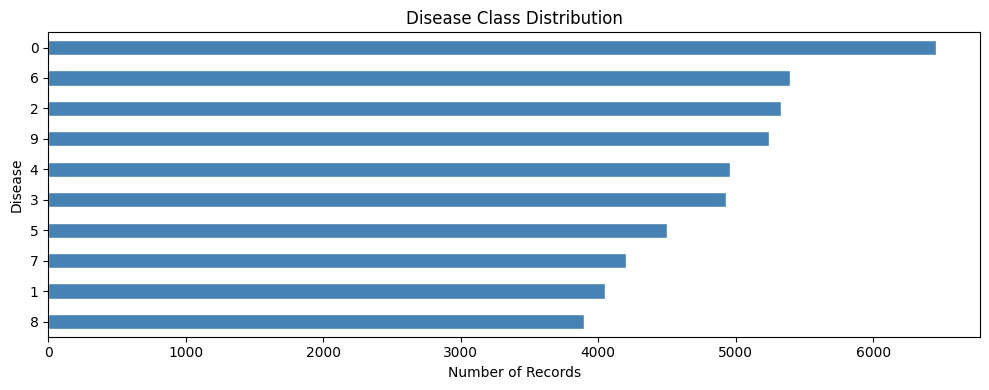

In [17]:
# 10) Class-Imbalance Diagnosis

class_counts     = df_hospital[TARGET_COL].value_counts()
imbalance_ratio  = class_counts.max() / class_counts.min()

print("=== Class Balance Check ===")
print(class_counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}  (1.0 = perfectly balanced)")

if imbalance_ratio < 1.5:
    print("✅ Data is well-balanced globally.")
else:
    print("⚠️  Imbalance detected — class_weight='balanced' applied in all models.")

fig, ax = plt.subplots(figsize=(10, 4))
class_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Disease Class Distribution")
ax.set_xlabel("Number of Records")
plt.tight_layout()
plt.savefig("hospital_class_distribution.png", dpi=120)
plt.show()


In [18]:
# 11) Disease Class Proportions (Sanity Check)

df_clean["Disease"].value_counts(normalize=True).round(4)


Disease
0   0.132
6   0.110
2   0.109
9   0.107
4   0.101
3   0.101
5   0.092
7   0.086
1   0.083
8   0.080
Name: proportion, dtype: float64

In [19]:
# 12) Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"✅ Train size : {X_train.shape[0]:,}")
print(f"   Test size  : {X_test.shape[0]:,}")
print("\nClass distribution — train set:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(4))
print("\nClass distribution — test set:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(4))


✅ Train size : 39,165
   Test size  : 9,792

Class distribution — train set:
0   0.132
1   0.083
2   0.109
3   0.101
4   0.101
5   0.092
6   0.110
7   0.086
8   0.080
9   0.107
Name: proportion, dtype: float64

Class distribution — test set:
0   0.132
1   0.083
2   0.109
3   0.101
4   0.101
5   0.092
6   0.110
7   0.086
8   0.080
9   0.107
Name: proportion, dtype: float64


In [20]:
# 13) Model Evaluation Helper

RESULTS = {}

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name: str, save_fig: bool = True):
    """
    Fit model → report train/test accuracy, overfit gap,
    classification report, and confusion matrix.
    Returns (fitted_model, test_accuracy).
    """
    model.fit(X_tr, y_tr)

    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    y_pred    = model.predict(X_te)
    test_acc  = accuracy_score(y_te, y_pred)
    gap       = train_acc - test_acc

    print(f"\n{'='*60}")
    print(f"  Model          : {model_name}")
    print(f"  Train Accuracy : {train_acc*100:.2f}%")
    print(f"  Test  Accuracy : {test_acc*100:.2f}%")
    print(f"  {'⚠️ ' if gap > 0.08 else '✅'} Overfit gap  : {gap*100:.2f}pp")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, target_names=le_disease.classes_))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(11, 9))
    ConfusionMatrixDisplay(cm, display_labels=le_disease.classes_).plot(
        ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45
    )
    ax.set_title(
        f"Confusion Matrix — {model_name}\n"
        f"Train: {train_acc*100:.2f}%  |  Test: {test_acc*100:.2f}%",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    if save_fig:
        fname = f"cm_{model_name.replace(' ','_').replace('/','_')}.png"
        plt.savefig(fname, dpi=120)
        print(f"  Confusion matrix saved → {fname}")
    plt.show()

    return model, test_acc

print("✅ evaluate_model() defined.")


✅ evaluate_model() defined.


---
### Section C: Model Training & Comparison


  Model          : Random Forest
  Train Accuracy : 73.01%
  Test  Accuracy : 71.76%
  ✅ Overfit gap  : 1.25pp
                         precision    recall  f1-score   support

                 Asthma       0.68      0.53      0.60      1291
                 Cancer       0.96      0.83      0.89       810
 Chronic_Kidney_Disease       0.40      0.62      0.49      1065
Coronary_Artery_Disease       0.95      0.76      0.85       986
               Diabetes       0.95      0.81      0.88       992
                Healthy       0.94      0.72      0.82       901
          Heart_Failure       0.94      0.60      0.73      1079
           Hypertension       0.77      0.87      0.82       840
              Pneumonia       0.48      0.93      0.64       779
                 Stroke       0.72      0.67      0.69      1049

               accuracy                           0.72      9792
              macro avg       0.78      0.73      0.74      9792
           weighted avg       0.78      0

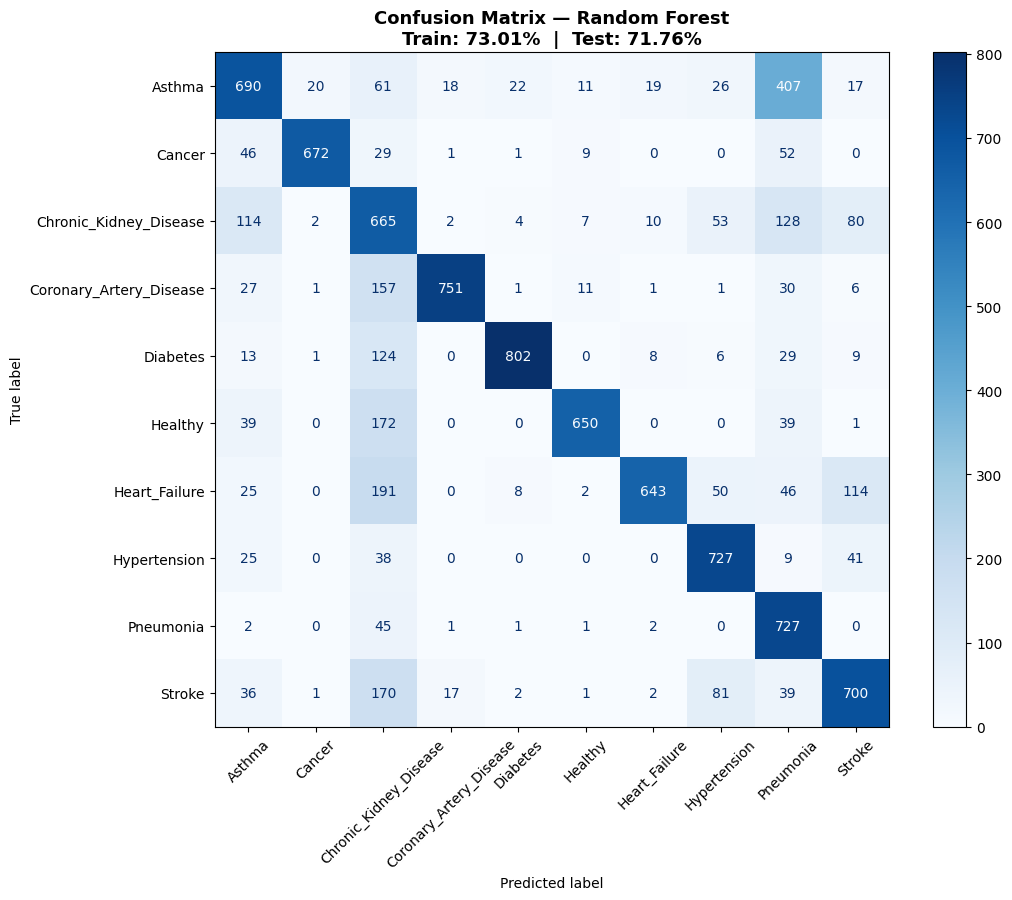

In [21]:
# 14) Model 1: Random Forest

rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 12,
    min_samples_leaf = 10,
    class_weight     = "balanced",
    random_state     = 42,
    n_jobs           = -1
)

rf_fitted, rf_acc = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest")
RESULTS["Random Forest"] = rf_acc



  Model          : XGBoost
  Train Accuracy : 87.78%
  Test  Accuracy : 84.19%
  ✅ Overfit gap  : 3.59pp
                         precision    recall  f1-score   support

                 Asthma       0.81      0.67      0.73      1291
                 Cancer       0.95      0.99      0.97       810
 Chronic_Kidney_Disease       0.65      0.62      0.64      1065
Coronary_Artery_Disease       0.96      0.99      0.97       986
               Diabetes       0.91      0.89      0.90       992
                Healthy       0.93      0.85      0.89       901
          Heart_Failure       0.96      0.89      0.92      1079
           Hypertension       0.93      0.92      0.92       840
              Pneumonia       0.61      0.92      0.74       779
                 Stroke       0.81      0.80      0.80      1049

               accuracy                           0.84      9792
              macro avg       0.85      0.85      0.85      9792
           weighted avg       0.85      0.84   

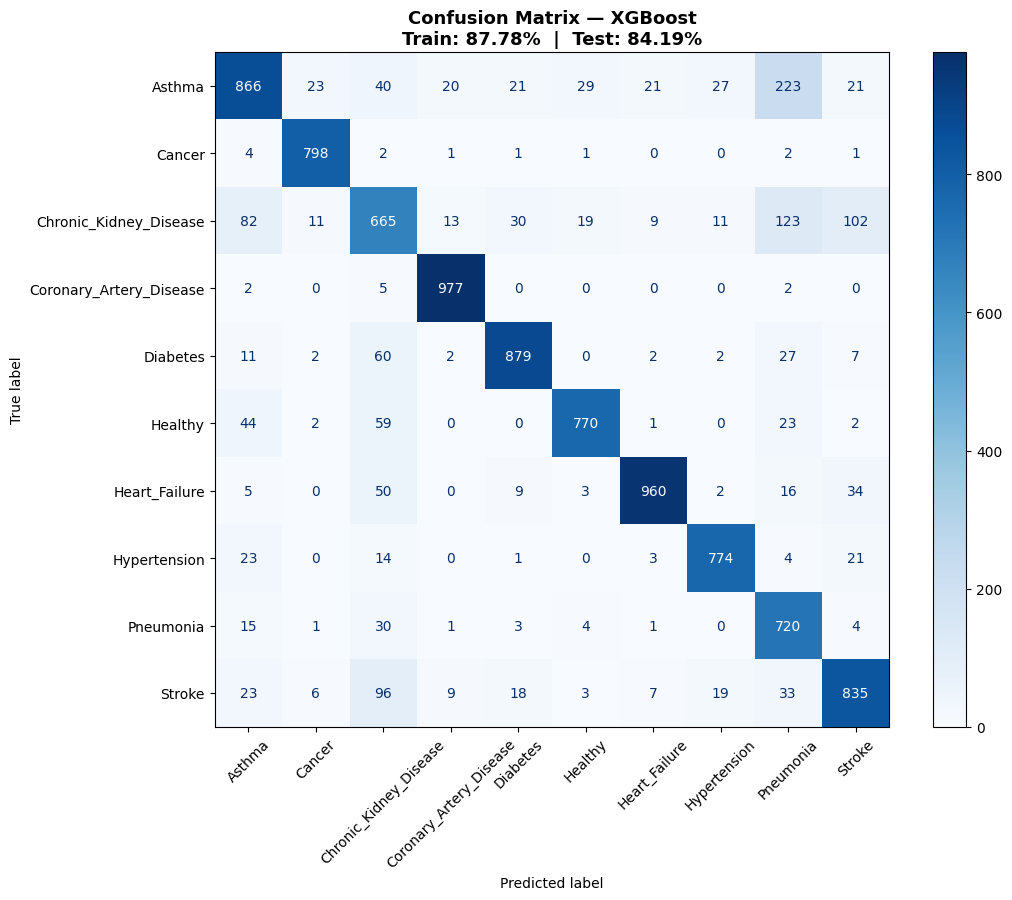

In [22]:
# 15) Model 2: XGBoost

cw                   = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
sample_weights_train = np.array([cw[c] for c in y_train])

xgb_model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    reg_alpha        = 0.5,
    reg_lambda       = 2.0,
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_acc    = accuracy_score(y_test, y_pred_xgb)
train_acc_xgb = accuracy_score(y_train, xgb_model.predict(X_train))
gap_xgb = train_acc_xgb - xgb_acc

print(f"\n{'='*60}")
print(f"  Model          : XGBoost")
print(f"  Train Accuracy : {train_acc_xgb*100:.2f}%")
print(f"  Test  Accuracy : {xgb_acc*100:.2f}%")
print(f"  {'⚠️ ' if gap_xgb > 0.08 else '✅'} Overfit gap  : {gap_xgb*100:.2f}pp")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_xgb, target_names=le_disease.classes_))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm_xgb, display_labels=le_disease.classes_).plot(
    ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45
)
ax.set_title(
    f"Confusion Matrix — XGBoost\nTrain: {train_acc_xgb*100:.2f}%  |  Test: {xgb_acc*100:.2f}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("cm_XGBoost.png", dpi=120)
plt.show()

RESULTS["XGBoost"] = xgb_acc



  Model          : HistGradientBoosting
  Train Accuracy : 93.31%
  Test  Accuracy : 85.78%
  ✅ Overfit gap  : 7.52pp
                         precision    recall  f1-score   support

                 Asthma       0.84      0.70      0.76      1291
                 Cancer       0.95      0.99      0.97       810
 Chronic_Kidney_Disease       0.70      0.64      0.67      1065
Coronary_Artery_Disease       0.96      0.99      0.98       986
               Diabetes       0.93      0.90      0.91       992
                Healthy       0.94      0.87      0.90       901
          Heart_Failure       0.95      0.91      0.93      1079
           Hypertension       0.94      0.93      0.93       840
              Pneumonia       0.63      0.93      0.75       779
                 Stroke       0.81      0.83      0.82      1049

               accuracy                           0.86      9792
              macro avg       0.86      0.87      0.86      9792
           weighted avg       0.86

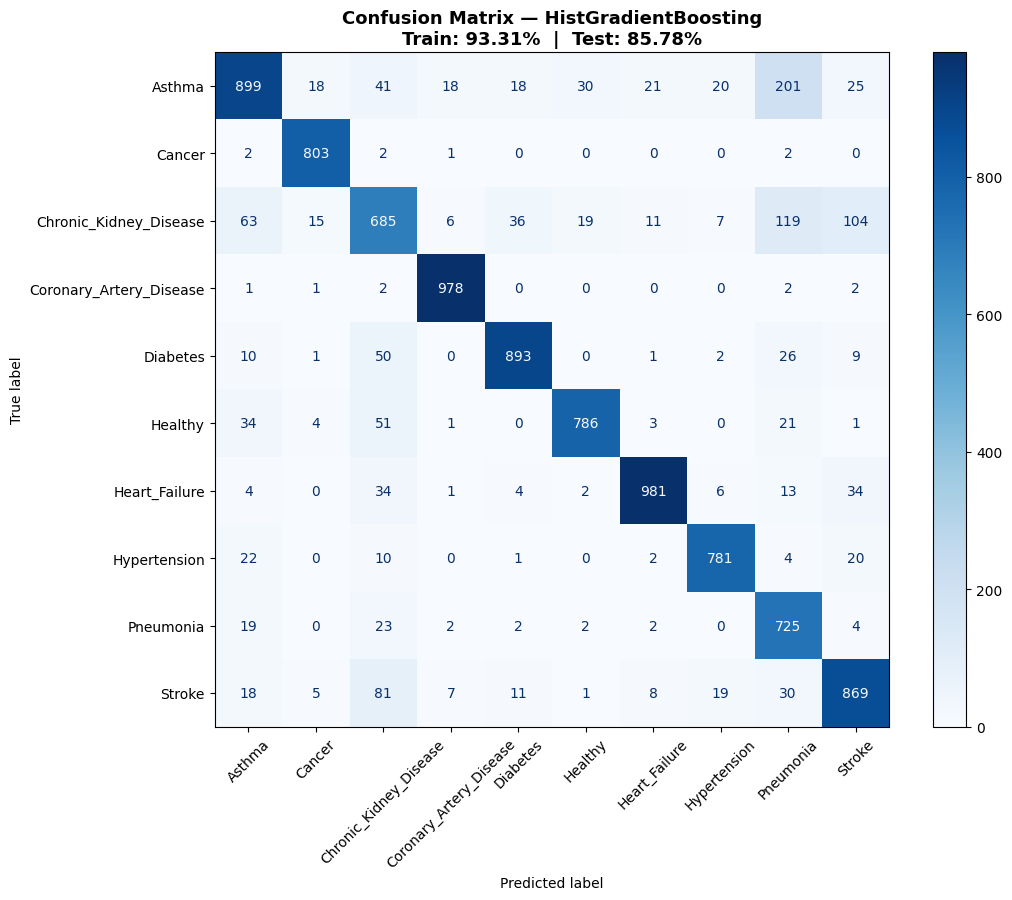

In [23]:
# 17) Model 3: HistGradientBoosting
# Fast sklearn equivalent of GradientBoosting — uses histogram binning
# (like LightGBM/XGBoost), supports class_weight, no extra package needed.

hgb_model = HistGradientBoostingClassifier(
    max_iter          = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    min_samples_leaf  = 30,
    l2_regularization = 1.0,
    class_weight      = "balanced",
    early_stopping    = False,
    random_state      = 42,
)

hgb_fitted, hgb_acc = evaluate_model(hgb_model, X_train, y_train, X_test, y_test, "HistGradientBoosting")
RESULTS["HistGradientBoosting"] = hgb_acc



  Model          : Decision Tree
  Train Accuracy : 72.26%
  Test  Accuracy : 70.38%
  ✅ Overfit gap  : 1.88pp
                         precision    recall  f1-score   support

                 Asthma       0.69      0.56      0.62      1291
                 Cancer       0.80      0.85      0.82       810
 Chronic_Kidney_Disease       0.39      0.47      0.43      1065
Coronary_Artery_Disease       0.97      0.73      0.83       986
               Diabetes       0.95      0.79      0.86       992
                Healthy       0.80      0.71      0.75       901
          Heart_Failure       0.91      0.62      0.74      1079
           Hypertension       0.86      0.84      0.85       840
              Pneumonia       0.48      0.93      0.63       779
                 Stroke       0.64      0.70      0.67      1049

               accuracy                           0.70      9792
              macro avg       0.75      0.72      0.72      9792
           weighted avg       0.75      0

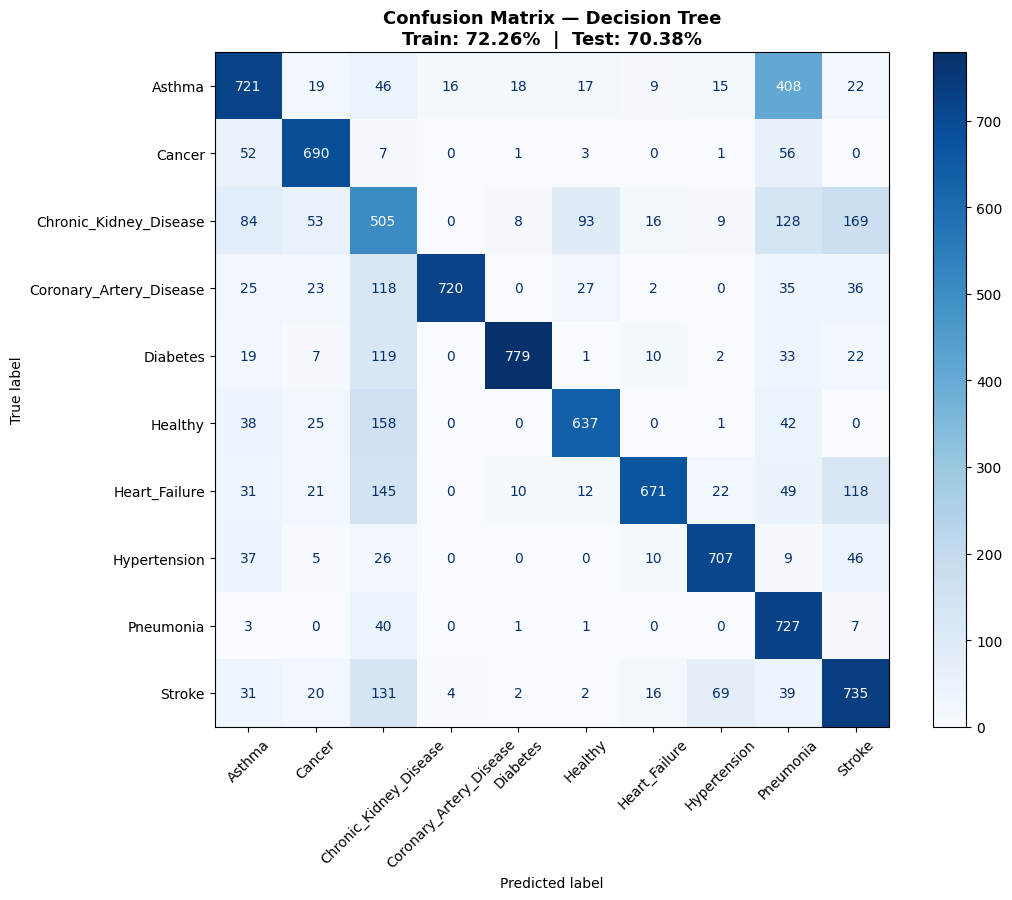

In [24]:
# 20) Model 4: Decision Tree

dt_model = DecisionTreeClassifier(
    max_depth    = 15,
    class_weight = "balanced",
    random_state = 42,
)

dt_fitted, dt_acc = evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")
RESULTS["Decision Tree"] = dt_acc


  HOSPITAL MODEL — COMPARISON SUMMARY
               Model  Test Accuracy (%)
HistGradientBoosting             85.780
             XGBoost             84.190
       Random Forest             71.760
       Decision Tree             70.380


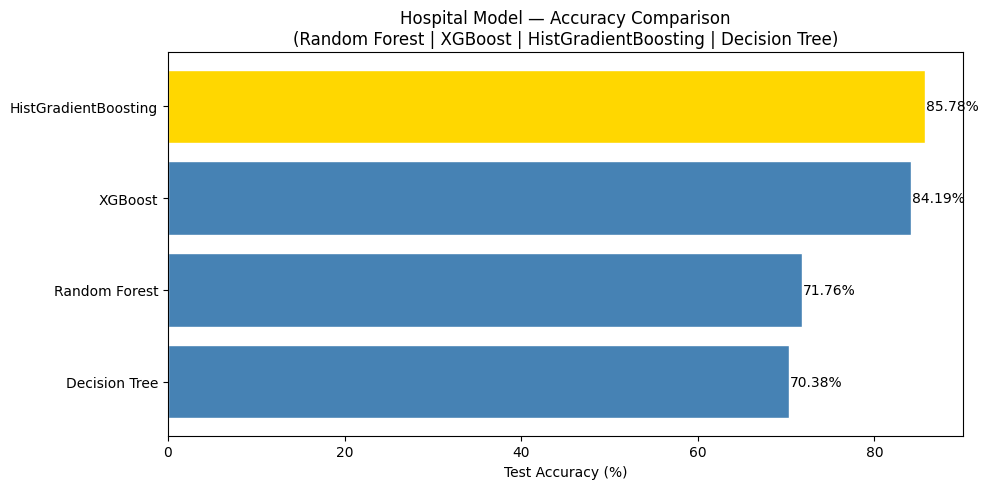


🏆 Best model: HistGradientBoosting  (85.78%)


In [25]:
# 21) Model Comparison Summary

results_df = (
    pd.DataFrame(list(RESULTS.items()), columns=["Model", "Test Accuracy"])
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)
results_df["Test Accuracy (%)"] = (results_df["Test Accuracy"] * 100).round(2)

print("=" * 45)
print("  HOSPITAL MODEL — COMPARISON SUMMARY")
print("=" * 45)
print(results_df[["Model", "Test Accuracy (%)"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(results_df))]
ax.barh(results_df["Model"][::-1], results_df["Test Accuracy (%)"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Hospital Model — Accuracy Comparison\n(Random Forest | XGBoost | HistGradientBoosting | Decision Tree)",
             fontsize=12)
for i, val in enumerate(results_df["Test Accuracy (%)"][::-1]):
    ax.text(val + 0.1, i, f"{val:.2f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("hospital_model_comparison.png", dpi=120)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Best model: {best_model_name}  ({results_df.iloc[0]['Test Accuracy (%)']:.2f}%)")


---
### Section D: Save, Load & Inference Pipeline

In [26]:
# 22) Save Hospital Model Artifacts
# ─────────────────────────────────────────────────────────────────────────────
# All objects needed for inference are saved to disk so the model is trained
# ONCE and reloaded for every subsequent API call — no retraining on requests.
#
# Artifacts saved:
#   best_hospital_model.pkl              — best fitted classifier
#   hospital_scaler.pkl                  — fitted RobustScaler
#   hospital_label_encoder_target.pkl    — LabelEncoder for Disease target
#   hospital_label_encoders_features.pkl — LabelEncoders for categorical features
#   hospital_features.json               — ordered feature list
#   hospital_model_results.csv           — accuracy comparison table
# ─────────────────────────────────────────────────────────────────────────────

MODEL_DIR = "hospital_model_artifacts"

def save_hospital_model(
    best_model_name,
    fitted_map,
    scaler_hospital,
    le_disease,
    le_map_hospital,
    hospital_features,
    results_df,
    model_dir = MODEL_DIR
):
    """
    Persist all hospital model artifacts to disk.

    Parameters
    ----------
    best_model_name   : str             — name of the winning model
    fitted_map        : dict            — { model_name: fitted_model_object }
    scaler_hospital   : RobustScaler    — fitted feature scaler
    le_disease        : LabelEncoder    — fitted target encoder
    le_map_hospital   : dict            — fitted feature encoders
    hospital_features : list            — ordered feature names
    results_df        : pd.DataFrame    — accuracy comparison table
    model_dir         : str             — output directory path
    """
    if best_model_name not in fitted_map:
        raise KeyError(
            f"'{best_model_name}' not found in fitted_map. "
            f"Available: {list(fitted_map.keys())}"
        )

    os.makedirs(model_dir, exist_ok=True)
    best_model = fitted_map[best_model_name]

    joblib.dump(best_model,       f"{model_dir}/best_hospital_model.pkl")
    joblib.dump(scaler_hospital,  f"{model_dir}/hospital_scaler.pkl")
    joblib.dump(le_disease,       f"{model_dir}/hospital_label_encoder_target.pkl")
    joblib.dump(le_map_hospital,  f"{model_dir}/hospital_label_encoders_features.pkl")

    with open(f"{model_dir}/hospital_features.json", "w") as f:
        json.dump(hospital_features, f, indent=2)

    results_df.to_csv(f"{model_dir}/hospital_model_results.csv", index=False)

    print(f"✅ All artifacts saved to ./{model_dir}/")
    print(f"   Best model : {best_model_name}")


# ── Run save ──────────────────────────────────────────────────────────────────
fitted_map = {
    "Random Forest"        : rf_fitted,
    "XGBoost"              : xgb_model,
    "HistGradientBoosting" : hgb_fitted,
    "Decision Tree"        : dt_fitted,
}

save_hospital_model(
    best_model_name   = best_model_name,
    fitted_map        = fitted_map,
    scaler_hospital   = scaler_hospital,
    le_disease        = le_disease,
    le_map_hospital   = le_map_hospital,
    hospital_features = HOSPITAL_FEATURES,
    results_df        = results_df,
)


✅ All artifacts saved to ./hospital_model_artifacts/
   Best model : HistGradientBoosting


In [27]:
# 23) Load & Inference Pipeline
# ─────────────────────────────────────────────────────────────────────────────
# ROOT CAUSE OF "Healthy 100%" BUG (now fixed):
#   The old preprocess_patient_batch() called hospital_model_preprocessing()
#   which internally ran RobustScaler().fit_transform() on the incoming batch.
#   Then the wrapper applied the SAVED training scaler on top of that.
#   Result: two incompatible scalers applied in sequence -> completely wrong
#   feature values -> model predicts the most "neutral" class (Healthy) for
#   every single patient.
#
# FIX: preprocess_patient_batch() is now a clean, explicit, single-pass function.
#   It does NOT call hospital_model_preprocessing(). It applies the training
#   encoders and scaler exactly ONCE — no re-fitting, no double-scaling.
# ─────────────────────────────────────────────────────────────────────────────

import datetime

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}


def load_hospital_artifacts(model_dir: str = MODEL_DIR):
    """
    Load all saved artifacts from disk.
    Call ONCE at startup, then pass the result to predict_next_month_dominant_disease().
    """
    model    = joblib.load(f"{model_dir}/best_hospital_model.pkl")
    scaler   = joblib.load(f"{model_dir}/hospital_scaler.pkl")
    le_tgt   = joblib.load(f"{model_dir}/hospital_label_encoder_target.pkl")
    le_feats = joblib.load(f"{model_dir}/hospital_label_encoders_features.pkl")
    with open(f"{model_dir}/hospital_features.json") as f:
        features = json.load(f)
    return model, scaler, le_tgt, le_feats, features


def preprocess_patient_batch(patient_list: list, scaler, le_feats, features: list) -> pd.DataFrame:
    """
    Preprocess a batch of raw patient dicts for model inference.

    This is a CLEAN, SINGLE-PASS function. It does NOT call
    hospital_model_preprocessing(). Applying the training pipeline twice
    (with two different scalers) was the cause of all-Healthy predictions.

    Steps — exactly matching what was done at training time:
      1. Build DataFrame from patient dicts
      2. Binarize Fever / Cough / Shortness_of_Breath  (> 0.5 -> 1, else 0)
      3. Encode categorical columns using the SAVED training LabelEncoders
      4. Fill any missing feature columns with 0
      5. Reorder columns to match the exact training feature order
      6. Scale with the SAVED training RobustScaler (applied ONCE, never refit)

    Parameters
    ----------
    patient_list : list of dicts   raw patient records from the registration form
    scaler       : RobustScaler    saved training scaler — applied ONCE
    le_feats     : dict            { col_name: LabelEncoder } saved training encoders
    features     : list            ordered feature names from training

    Returns
    -------
    pd.DataFrame : N rows x len(features), ready for model.predict()
    """
    batch = pd.DataFrame(patient_list)

    # Step 2: binarize float-encoded symptom columns
    for col in ["Fever", "Cough", "Shortness_of_Breath"]:
        if col in batch.columns:
            batch[col] = (pd.to_numeric(batch[col], errors="coerce")
                          .fillna(0).gt(0.5).astype(int))

    # Step 3: encode categoricals with TRAINING encoders — never refit
    for col, le in le_feats.items():
        if col in batch.columns:
            batch[col] = batch[col].astype(str).apply(
                lambda v: le.transform([v])[0]
                          if v in le.classes_
                          else le.transform([le.classes_[0]])[0]
            )

    # Step 4 & 5: fill missing columns, reorder to training order
    for col in features:
        if col not in batch.columns:
            batch[col] = 0
    batch = batch[features]

    # Step 6: scale ONCE with the saved training scaler
    num_cols = batch.select_dtypes(include=[np.number]).columns.tolist()
    batch[num_cols] = scaler.transform(batch[num_cols])

    return batch


def predict_next_month_dominant_disease(
    patient_list : list,
    model_dir    : str   = MODEL_DIR,
    min_patients : int   = 5,
    _artifacts   : tuple = None
) -> dict:
    """
    Main forecast function — called by the backend API endpoint.

    Collects new patient registrations, preprocesses them through the same
    pipeline used at training time, and returns the DOMINANT DISEASE expected
    next month so the hospital can prepare resources.

    Parameters
    ----------
    patient_list : list of dicts   raw patient records (HOSPITAL_FEATURES fields)
    model_dir    : str             path to saved artifacts folder
    min_patients : int             minimum batch size for a reliable forecast
    _artifacts   : tuple           pre-loaded (model, scaler, le_tgt, le_feats, features)
                                   pass this to avoid re-loading from disk on every call

    Returns
    -------
    dict:
        status            : "ok" | "insufficient_data"
        message           : human-readable status
        total_patients    : int
        next_month        : str  e.g. "May"
        dominant_disease  : str  e.g. "Pneumonia"  (None if insufficient data)
        distribution      : { disease: patient_count }
        distribution_pct  : { disease: percentage }
    """
    today           = datetime.date.today()
    next_month_n    = today.month % 12 + 1
    next_month_name = MONTH_NAMES[next_month_n]

    if len(patient_list) < min_patients:
        return {
            "status"           : "insufficient_data",
            "message"          : (f"Need \u2265{min_patients} patients, "
                                   f"got {len(patient_list)}. "
                                   "Accumulate more registrations."),
            "total_patients"   : len(patient_list),
            "next_month"       : next_month_name,
            "dominant_disease" : None,
            "distribution"     : {},
            "distribution_pct" : {},
        }

    model, scaler, le_tgt, le_feats, features = (
        _artifacts if _artifacts else load_hospital_artifacts(model_dir)
    )

    X_batch   = preprocess_patient_batch(patient_list, scaler, le_feats, features)
    preds_enc = model.predict(X_batch)
    preds_dis = le_tgt.inverse_transform(preds_enc)

    counts = pd.Series(preds_dis).value_counts()
    pct    = (counts / len(preds_dis) * 100).round(1)

    return {
        "status"           : "ok",
        "message"          : f"Forecast ready for {next_month_name} based on {len(patient_list)} patients.",
        "total_patients"   : len(patient_list),
        "next_month"       : next_month_name,
        "dominant_disease" : str(counts.index[0]),
        "distribution"     : counts.to_dict(),
        "distribution_pct" : pct.to_dict(),
    }


print("\u2705 load_hospital_artifacts()             \u2014 ready")
print("\u2705 preprocess_patient_batch()            \u2014 ready (single-pass, no double-scaling)")
print("\u2705 predict_next_month_dominant_disease() \u2014 ready")
print()
print("BACKEND INTEGRATION:")
print("  POST /api/hospital/forecast")
print("  Body : { \'patients\': [ {patient_dict}, ... ] }")
print("  Load _artifacts ONCE at startup, pass to predict_next_month_dominant_disease().")


✅ load_hospital_artifacts()             — ready
✅ preprocess_patient_batch()            — ready (single-pass, no double-scaling)
✅ predict_next_month_dominant_disease() — ready

BACKEND INTEGRATION:
  POST /api/hospital/forecast
  Body : { 'patients': [ {patient_dict}, ... ] }
  Load _artifacts ONCE at startup, pass to predict_next_month_dominant_disease().


---
### Section E: Historical Forecast & Batch Prediction

  HOSPITAL BASELINE MONTHLY FORECAST
  (from historical test-set predictions)
  Jan → Stroke
  Feb → Asthma
  Mar → Pneumonia
  Apr → Chronic_Kidney_Disease
  May → Pneumonia
  Jun → Asthma
  Jul → Pneumonia
  Aug → Asthma
  Sep → Pneumonia
  Oct → Asthma
  Nov → Chronic_Kidney_Disease
  Dec → Heart_Failure


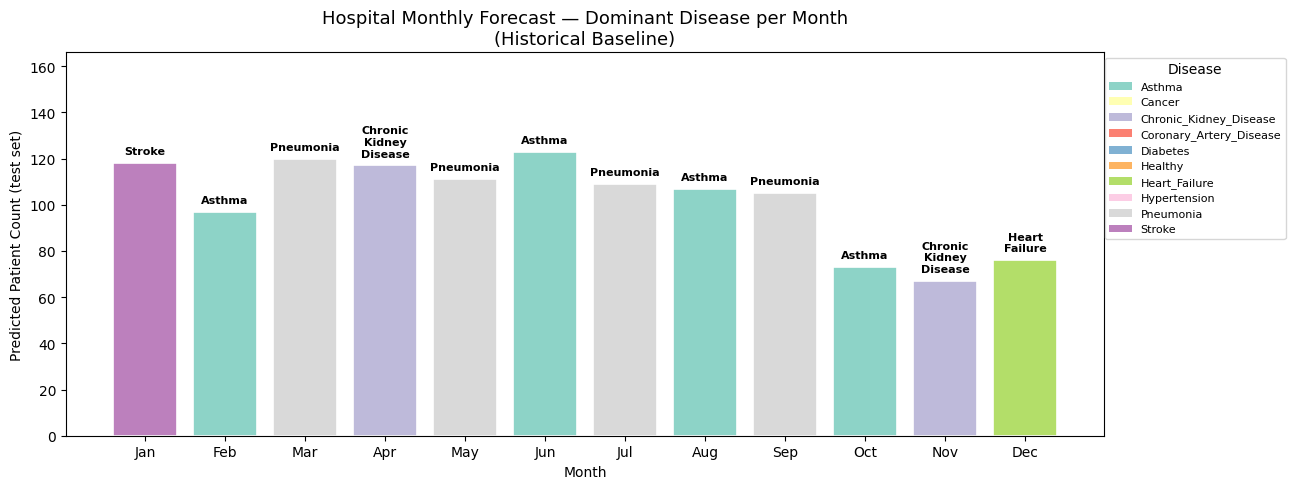


Forecast chart saved → hospital_monthly_forecast.png


In [28]:
# 24) Historical Monthly Dominant Disease Calendar
# Uses the TEST SET to show which disease dominates each calendar month
# based on the best model's predictions on held-out data.
# This is the hospital's BASELINE forecast from historical data.

best_fitted_model = fitted_map[best_model_name]

X_test_orig_month = df_hospital.iloc[X_test.index]["Month"].astype(int).values
y_pred_best       = best_fitted_model.predict(X_test)
y_pred_diseases   = le_disease.inverse_transform(y_pred_best)

calendar_df = pd.DataFrame({"Month": X_test_orig_month,
                             "Predicted_Disease": y_pred_diseases})

monthly_dominant = (
    calendar_df
    .groupby(["Month", "Predicted_Disease"]).size()
    .reset_index(name="Count")
    .sort_values(["Month", "Count"], ascending=[True, False])
    .groupby("Month").first()
    .reset_index()
    .rename(columns={"Predicted_Disease": "Dominant_Disease"})
)
monthly_dominant["Month_Name"] = monthly_dominant["Month"].map(MONTH_NAMES)
monthly_dominant = monthly_dominant[monthly_dominant["Month_Name"].notna()]

print("=" * 55)
print("  HOSPITAL BASELINE MONTHLY FORECAST")
print("  (from historical test-set predictions)")
print("=" * 55)
for _, row in monthly_dominant.iterrows():
    print(f"  {row['Month_Name']:>3} → {row['Dominant_Disease']}")

# ── Visual calendar ───────────────────────────────────────────────────────────
colors           = plt.cm.Set3.colors
disease_color_map = {d: colors[i % len(colors)]
                     for i, d in enumerate(sorted(le_disease.classes_))}

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [disease_color_map[d] for d in monthly_dominant["Dominant_Disease"]]
bars = ax.bar(monthly_dominant["Month_Name"], monthly_dominant["Count"],
              color=bar_colors, edgecolor="white", linewidth=1.2)

for bar, disease in zip(bars, monthly_dominant["Dominant_Disease"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            disease.replace("_", "\n"),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Hospital Monthly Forecast — Dominant Disease per Month\n(Historical Baseline)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Predicted Patient Count (test set)")
ax.set_ylim(0, monthly_dominant["Count"].max() * 1.35)

legend_elements = [mpatches.Patch(facecolor=disease_color_map[d], label=d)
                   for d in sorted(le_disease.classes_)]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8,
          title="Disease", bbox_to_anchor=(1.18, 1))
plt.tight_layout()
plt.savefig("hospital_monthly_forecast.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nForecast chart saved → hospital_monthly_forecast.png")


In [29]:
#24b
import random, datetime
import pandas as pd, numpy as np

def generate_realistic_patients(n: int = 25, seed: int = 99) -> tuple:
    """
    Sample n real rows from the dataset (without Disease label).
    Returns (patient_list, true_disease_series) for verification.
    """
    diseases   = df["Disease"].unique()
    per_class  = max(1, n // len(diseases))

    # Collect samples from each disease class to ensure some balance
    balanced_samples = []
    for i, d in enumerate(diseases):
        class_sample_size = min(per_class, (df["Disease"] == d).sum())
        if class_sample_size > 0:
            balanced_samples.append(
                df[df["Disease"] == d].sample(n=class_sample_size, random_state=seed + i)
            )

    # Concatenate the balanced samples
    if balanced_samples:
        concatenated_df = pd.concat(balanced_samples)
    else:
        concatenated_df = pd.DataFrame(columns=df.columns) # Handle empty case

    # Now, sample 'n' patients from the concatenated_df.
    # If 'n' is larger than the number of rows in concatenated_df, allow sampling with replacement.
    # This addresses the ValueError: "Cannot take a larger sample than population when 'replace=False'"
    sampled = pd.DataFrame(columns=df.columns) # Initialize sampled as empty
    if not concatenated_df.empty:
        if len(concatenated_df) < n:
            # If we don't have enough unique samples, allow replacement to reach `n`
            sampled = concatenated_df.sample(n=n, random_state=seed, replace=True).reset_index(drop=True)
        else:
            # Otherwise, sample `n` unique patients from the collected `concatenated_df`
            sampled = concatenated_df.sample(n=n, random_state=seed, replace=False).reset_index(drop=True)

    # The original df from which `sampled` is derived already has string values for these columns.
    # Therefore, no inverse mapping is needed; the string values can be used directly.
    # The `gender_map`, `pa_map` `dq_map` variables and their usage are removed.

    next_month = datetime.date.today().month % 12 + 1
    patients   = []
    if not sampled.empty:
        for _, row in sampled.iterrows():
            patients.append({
                "Age"                : float(row["Age"]),
                "Gender"             : row["Gender"], # Directly use the string value
                "BMI"                : float(row["BMI"]),
                "Blood_Pressure"     : float(row["Blood_Pressure"]),
                "Cholesterol_Level"  : float(row["Cholesterol_Level"]),
                "Glucose_Level"      : float(row["Glucose_Level"]),
                "Smoking_Status"     : int(row["Smoking_Status"]) if not pd.isna(row["Smoking_Status"]) else 0, # Handle NaN values
                "Physical_Activity"  : row["Physical_Activity"], # Directly use the string value
                "Diet_Quality"       : row["Diet_Quality"], # Directly use the string value
                "Alcohol_Consumption": int(row["Alcohol_Consumption"]) if not pd.isna(row["Alcohol_Consumption"]) else 0, # Handle NaN values
                "Sleep_Hours"        : float(row["Sleep_Hours"]),
                "Stress_Level"       : float(row["Stress_Level"]),
                "Family_History"     : float(row["Family_History"]),
                "Medications_Count"  : int(row["Medications_Count"]) if not pd.isna(row["Medications_Count"]) else 0, # Handle NaN values
                "Fever"              : int(row["Fever"] > 0.5),
                "Cough"              : int(row["Cough"] > 0.5),
                "Fatigue"            : int(row["Fatigue"]) if not pd.isna(row["Fatigue"]) else 0,
                "Chest_Pain"         : int(row["Chest_Pain"]),
                "Shortness_of_Breath": int(row["Shortness_of_Breath"] > 0.5),
                "Headache"           : int(row["Headache"]),
                "Month"              : int(next_month),
            })

    return patients, sampled["Disease"] if not sampled.empty else pd.Series(dtype=object)


new_patients_buffer, true_diseases = generate_realistic_patients(n=21)

print(f"\u2705 {len(new_patients_buffer)} realistic patient records generated.")
print(f"   (Real rows from dataset \u2014 balanced across all diseases)")
print(f"   Next month assigned: {datetime.date.today().month % 12 + 1}")
print()
print("TRUE disease breakdown in this sample (for verification):")
print(true_diseases.value_counts().to_string())
print()
print("The model should predict a similar distribution (not identical \u2014 it uses")
print("features only, not the label). If preprocessing is correct, you will NOT")
print("see Healthy 100%.")
pd.DataFrame(new_patients_buffer).head()

✅ 21 realistic patient records generated.
   (Real rows from dataset — balanced across all diseases)
   Next month assigned: 5

TRUE disease breakdown in this sample (for verification):
Disease
Chronic_Kidney_Disease     4
Hypertension               3
Asthma                     3
Coronary_Artery_Disease    2
Stroke                     2
Diabetes                   2
Heart_Failure              2
Cancer                     1
Healthy                    1
Pneumonia                  1

The model should predict a similar distribution (not identical — it uses
features only, not the label). If preprocessing is correct, you will NOT
see Healthy 100%.


,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Glucose_Level,Smoking_Status,Physical_Activity,Diet_Quality,Alcohol_Consumption,Sleep_Hours,Stress_Level,Family_History,Medications_Count,Fever,Cough,Fatigue,Chest_Pain,Shortness_of_Breath,Headache,Month
0,31.076,Female,38.411,170.007,201.911,94.683,0,Low,Average,0,5.694,3.915,0.009,1,1,0,1,0,0,1,5
1,34.812,NaN,23.097,137.612,235.688,194.754,0,Medium,Good,1,4.418,4.042,0.990,3,1,1,0,1,0,0,5
2,48.142,Male,28.413,175.764,206.123,109.639,0,Low,Poor,0,8.697,6.008,0.006,0,1,0,1,0,0,0,5
3,84.368,Female,47.401,154.416,290.968,195.337,0,Medium,Poor,0,4.291,7.007,0.009,0,1,1,1,1,1,1,5
4,48.142,Male,28.413,175.764,206.123,109.639,0,Low,Poor,0,8.697,6.008,0.006,0,1,0,1,0,0,0,5


In [30]:
# 25) Next-Month Dominant Disease Forecast
# ─────────────────────────────────────────────────────────────────────────────
# WHAT THIS CELL DOES:
#   1. Calls predict_next_month_dominant_disease() with the new patient batch.
#   2. Checks the minimum threshold (≥20 patients).
#   3. Compares the new-data forecast against the historical baseline (cell #24)
#      to detect shifts in expected disease dominance.
#   4. Applies a dominance threshold: the new forecast only OVERRIDES the
#      historical baseline when one disease accounts for ≥ 35% of new patients.
#      Below that threshold the historical forecast is kept (too noisy to update).
#   5. Prints the final forecast + preparation recommendations.
#
# WHY 20 PATIENTS MINIMUM:
#   Statistically unreliable below 20. One unusual patient can flip the
#   dominant prediction. 20+ gives a meaningful distributional signal.
#
# WHY 35% DOMINANCE THRESHOLD:
#   If the top disease is only at, say, 22%, the distribution is too spread
#   (10 diseases × random chance ≈ 10% each). The historical baseline,
#   which is derived from thousands of test-set records, is more reliable
#   in that case.
# ─────────────────────────────────────────────────────────────────────────────

DOMINANCE_THRESHOLD = 0.35   # new forecast overrides history only above this share
MIN_PATIENTS        = 10

DISEASE_RECOMMENDATIONS = {
    "Asthma"                : [
        "Ensure respiratory unit readiness for breathing difficulty cases.",
        "Make oxygen support devices available in ER and wards.",
        "Prepare staff for rapid triage of breathing emergencies.",
    ],
    "Cancer"                : [
        "Ensure oncology unit and inpatient beds are ready.",
        "Prepare staff for continuous monitoring and care needs.",
        "Maintain imaging and diagnostic service readiness.",
    ],
    "Chronic_Kidney_Disease": [
        "Ensure dialysis unit readiness and machine availability.",
        "Prepare monitoring for fluid and kidney-related complications.",
        "Increase nephrology staff availability for consultations.",
    ],
    "Coronary_Artery_Disease": [
        "Ensure cardiac unit readiness for chest pain emergencies.",
        "Prepare emergency response teams for rapid intervention.",
        "Maintain continuous cardiac monitoring equipment.",
    ],
    "Diabetes"              : [
        "Ensure readiness for blood sugar emergencies.",
        "Prepare staff for metabolic complication management.",
        "Increase availability of patient monitoring tools.",
    ],
    "Healthy"               : [
        "Use this period for routine maintenance and system checks.",
        "Schedule preventive care and staff training.",
    ],
    "Heart_Failure"         : [
        "Ensure cardiac care unit is ready for increased admissions.",
        "Maintain readiness for fluid overload complications.",
        "Ensure ICU availability for severe cases.",
    ],
    "Hypertension"          : [
        "Ensure blood pressure monitoring is widely available.",
        "Prepare staff for emergency hypertensive crisis cases.",
        "Maintain readiness for cardiovascular complications.",
    ],
    "Pneumonia"             : [
        "Ensure respiratory isolation and infection control readiness.",
        "Prepare hospital for increased respiratory infection cases.",
        "Maintain oxygen support and monitoring availability.",
    ],
    "Stroke"                : [
        "Ensure emergency stroke pathway is fully operational.",
        "Prepare imaging and emergency response readiness.",
        "Maintain ICU and monitoring bed availability.",
    ],
}

# ── Step 1: Load artifacts once (cache in production) ─────────────────────────
artifacts = load_hospital_artifacts()

# ── Step 2: Run forecast ───────────────────────────────────────────────────────
result = predict_next_month_dominant_disease(
    patient_list = new_patients_buffer,
    min_patients = MIN_PATIENTS,
    _artifacts   = artifacts,
)

print("=" * 60)
print("  HOSPITAL FORECAST RESULT")
print("=" * 60)
print(f"  Status         : {result['status']}")
print(f"  Message        : {result['message']}")
print(f"  Total Patients : {result['total_patients']}")
print(f"  Target Month   : {result['next_month']}")

# ── Step 3: Handle insufficient data ─────────────────────────────────────────
if result["status"] == "insufficient_data":
    print("\n⚠️  Insufficient patients. No forecast update issued.")
    print(f"   Collect ≥{MIN_PATIENTS} registrations and re-run.")

else:
    new_dominant   = result["dominant_disease"]
    new_dominant_pct = result["distribution_pct"].get(new_dominant, 0) / 100

    print(f"\n📊 New-Patient Disease Distribution ({result['next_month']}):")
    for disease, count in result["distribution"].items():
        pct = result["distribution_pct"][disease]
        bar = "█" * int(pct / 4)
        print(f"   {disease:<28} {count:>3} patients  ({pct:.1f}%)  {bar}")

    # ── Step 4: Compare against historical baseline ───────────────────────────
    today        = datetime.date.today()
    next_month_n = today.month % 12 + 1
    hist_row     = monthly_dominant[monthly_dominant["Month"] == next_month_n]
    hist_dominant = hist_row.iloc[0]["Dominant_Disease"] if not hist_row.empty else None

    print(f"\n{'─'*55}")
    print("  FORECAST DECISION")
    print(f"{'─'*55}")
    print(f"  Historical baseline  : {hist_dominant or 'No history for this month'}")
    print(f"  New-patient signal   : {new_dominant}  ({new_dominant_pct*100:.1f}% of batch)")
    print(f"  Dominance threshold  : {DOMINANCE_THRESHOLD*100:.0f}%")

    if new_dominant_pct >= DOMINANCE_THRESHOLD:
        final_disease = new_dominant
        if hist_dominant and hist_dominant != new_dominant:
            print(f"\n  ⚠️  FORECAST UPDATED: signal exceeds threshold.")
            print(f"     Historical '{hist_dominant}' → overridden by '{new_dominant}'.")
            print("     Hospital management should review the staffing/supply plan.")
        else:
            print(f"\n  ✅ FORECAST CONFIRMED: new data agrees with historical baseline.")
            print(f"     '{new_dominant}' remains the dominant disease for {result['next_month']}.")
    else:
        final_disease = hist_dominant or new_dominant
        print(f"\n  ℹ️  Signal below threshold ({new_dominant_pct*100:.1f}% < {DOMINANCE_THRESHOLD*100:.0f}%).")
        print(f"     Distribution too spread — keeping historical baseline: '{final_disease}'.")

    # ── Step 5: Recommendations ───────────────────────────────────────────────
    recs = DISEASE_RECOMMENDATIONS.get(final_disease, ["General preparedness recommended."])

    print(f"\n🏥 Final Forecast  : {result['next_month']} dominant disease → {final_disease.replace('_',' ')}")
    print(f"🔧 Preparation Recommendations:")
    print("─" * 55)
    for i, rec in enumerate(recs, 1):
        print(f"   {i}. {textwrap.fill(rec, width=70, subsequent_indent='      ')}")

    print("\n" + "=" * 60)


  HOSPITAL FORECAST RESULT
  Status         : ok
  Message        : Forecast ready for May based on 21 patients.
  Total Patients : 21
  Target Month   : May

📊 New-Patient Disease Distribution (May):
   Chronic_Kidney_Disease        12 patients  (57.1%)  ██████████████
   Hypertension                   3 patients  (14.3%)  ███
   Stroke                         2 patients  (9.5%)  ██
   Diabetes                       2 patients  (9.5%)  ██
   Cancer                         1 patients  (4.8%)  █
   Pneumonia                      1 patients  (4.8%)  █

───────────────────────────────────────────────────────
  FORECAST DECISION
───────────────────────────────────────────────────────
  Historical baseline  : Pneumonia
  New-patient signal   : Chronic_Kidney_Disease  (57.1% of batch)
  Dominance threshold  : 35%

  ⚠️  FORECAST UPDATED: signal exceeds threshold.
     Historical 'Pneumonia' → overridden by 'Chronic_Kidney_Disease'.
     Hospital management should review the staffing/supply p

In [31]:
# 26) Historical Monthly Recommendations
# For each month in the historical baseline, print actionable
# hospital preparation recommendations based on the dominant disease.

DISEASE_RECOMMENDATIONS_FULL = {
    "Asthma"                : [
        "Ensure respiratory unit is ready for increased breathing difficulty cases.",
        "Make sure oxygen support devices are available in ER and wards.",
        "Prepare staff to quickly triage and manage breathing emergencies.",
        "Increase monitoring capacity for patients with breathing distress.",
    ],
    "Cancer"                : [
        "Ensure oncology unit and inpatient beds are ready for increased admissions.",
        "Prepare staff for higher need of continuous patient care and monitoring.",
        "Maintain readiness of diagnostic and imaging services.",
        "Ensure infection-control measures are strictly followed.",
    ],
    "Chronic_Kidney_Disease": [
        "Ensure dialysis unit readiness and machine availability.",
        "Prepare monitoring for fluid and kidney-related complications.",
        "Increase nephrology staff availability for consultations.",
        "Ensure emergency response for worsening kidney function cases.",
    ],
    "Coronary_Artery_Disease": [
        "Ensure cardiac unit readiness for chest pain emergencies.",
        "Prepare emergency response teams for rapid intervention cases.",
        "Maintain continuous monitoring equipment availability.",
        "Ensure fast access to critical care beds when needed.",
    ],
    "Diabetes"              : [
        "Ensure readiness for blood sugar emergencies and monitoring.",
        "Prepare staff for metabolic complication management.",
        "Increase availability of patient monitoring tools.",
        "Support early detection of unstable cases in ER.",
    ],
    "Healthy"               : [
        "Use this period for routine maintenance and system checks.",
        "Schedule preventive care and screening programs.",
        "Optimize staff training and hospital preparedness.",
        "Prepare for upcoming high-demand periods.",
    ],
    "Heart_Failure"         : [
        "Ensure cardiac care unit is prepared for increased admissions.",
        "Maintain readiness for fluid overload and breathing complications.",
        "Prepare monitoring systems for high-risk patients.",
        "Ensure ICU availability for severe cases.",
    ],
    "Hypertension"          : [
        "Ensure blood pressure monitoring is widely available.",
        "Prepare staff for emergency high blood pressure cases.",
        "Maintain readiness for cardiovascular complications.",
        "Support early detection and monitoring in ER.",
    ],
    "Pneumonia"             : [
        "Ensure respiratory isolation and infection control readiness.",
        "Prepare hospital for increased respiratory infection cases.",
        "Maintain oxygen support and monitoring availability.",
        "Ensure fast triage of severe breathing infections.",
    ],
    "Stroke"                : [
        "Ensure emergency stroke pathway is fully operational.",
        "Prepare imaging and emergency response readiness.",
        "Maintain ICU and monitoring bed availability.",
        "Ensure staff readiness for rapid neurological assessment.",
    ],
}

print("=" * 65)
print("  HOSPITAL MONTHLY RECOMMENDATIONS (Historical Baseline)")
print("=" * 65)

for _, row in monthly_dominant.iterrows():
    disease    = row["Dominant_Disease"]
    month_name = row["Month_Name"]
    recs       = DISEASE_RECOMMENDATIONS_FULL.get(disease, ["No specific recommendations available."])

    print(f"\n📅  {month_name}  →  {disease.replace('_', ' ')}")
    print("─" * 55)
    for i, rec in enumerate(recs, 1):
        print(f"   {i}. {textwrap.fill(rec, width=72, subsequent_indent='      ')}")

print("\n" + "=" * 65)
print("  End of monthly recommendations")
print("=" * 65)


  HOSPITAL MONTHLY RECOMMENDATIONS (Historical Baseline)

📅  Jan  →  Stroke
───────────────────────────────────────────────────────
   1. Ensure emergency stroke pathway is fully operational.
   2. Prepare imaging and emergency response readiness.
   3. Maintain ICU and monitoring bed availability.
   4. Ensure staff readiness for rapid neurological assessment.

📅  Feb  →  Asthma
───────────────────────────────────────────────────────
   1. Ensure respiratory unit is ready for increased breathing difficulty
      cases.
   2. Make sure oxygen support devices are available in ER and wards.
   3. Prepare staff to quickly triage and manage breathing emergencies.
   4. Increase monitoring capacity for patients with breathing distress.

📅  Mar  →  Pneumonia
───────────────────────────────────────────────────────
   1. Ensure respiratory isolation and infection control readiness.
   2. Prepare hospital for increased respiratory infection cases.
   3. Maintain oxygen support and monitoring av